In [69]:
# CELL 1: IMPORTS AND BULLETPROOF LANGSMITH SETUP
# ============================================================================

import pandas as pd
import numpy as np
import requests
import os
import time
import random
import json
import hashlib
import faiss
import pickle
import sys
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Union, Any
from dataclasses import dataclass, asdict, field 
from enum import Enum
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from contextlib import contextmanager
from functools import wraps
from types import SimpleNamespace

# API clients
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
    print("✅ OpenAI library available")
except ImportError:
    print("❌ OpenAI not installed. Install with: pip install openai")
    OPENAI_AVAILABLE = False

try:
    from groq import Groq
    GROQ_AVAILABLE = True
    print("✅ Groq library available")
except ImportError:
    print("❌ Groq not installed. Install with: pip install groq")
    GROQ_AVAILABLE = False

# LangSmith imports
try:
    from langsmith import Client, traceable
    from langsmith.run_helpers import get_current_run_tree
    import langsmith
    LANGSMITH_AVAILABLE = True
    print("✅ LangSmith available")
except ImportError:
    LANGSMITH_AVAILABLE = False
    print("📝 LangSmith not available")

# Load environment variables
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("✅ Environment variables loaded")
except ImportError:
    print("📝 python-dotenv not found. Set environment variables manually.")

# ============================================================================
# BULLETPROOF LANGSMITH MANAGER - NO MORE ERRORS!
# ============================================================================

class BulletproofLangSmithManager:
    """Bulletproof LangSmith manager that never throws errors"""
    
    def __init__(self, api_key: str = None, project: str = None):
        self.api_key = api_key or os.getenv('LANGCHAIN_API_KEY')
        self.project = project or os.getenv('LANGCHAIN_PROJECT', 'enhanced-hybrid-beauty-classifier')
        self.client = None
        self.enabled = False
        
        # Setup with comprehensive error handling
        self._safe_setup()
    
    def _safe_setup(self):
        """Setup with bulletproof error handling"""
        if not LANGSMITH_AVAILABLE or not self.api_key:
            return
        
        try:
            os.environ["LANGCHAIN_TRACING_V2"] = "true"
            os.environ["LANGCHAIN_PROJECT"] = self.project
            os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
            os.environ["LANGCHAIN_API_KEY"] = self.api_key
            
            self.client = Client(
                api_url="https://api.smith.langchain.com",
                api_key=self.api_key
            )
            
            # Simple connection test
            try:
                list(self.client.list_runs(project_name=self.project, limit=1))
                self.enabled = True
                print("✅ LangSmith connection verified")
            except:
                self.enabled = False
                print("📝 LangSmith connection failed - continuing without observability")
                
        except Exception as e:
            self.enabled = False
            print(f"📝 LangSmith setup skipped: {str(e)[:50]}")
    
    def is_enabled(self) -> bool:
        """Check if LangSmith is enabled"""
        return self.enabled and self.client is not None
    
    def safe_log_event(self, event_type: str, data: Dict, run_id: str = None):
        """BULLETPROOF event logging - never throws errors"""
        if not self.is_enabled():
            return  # Silent return if not enabled
        
        try:
            # Strategy 1: Create a simple run for this event
            run = self.client.create_run(
                name=f"event_{event_type}",
                run_type="tool",
                project_name=self.project,
                inputs={"event_type": event_type},
                outputs=data,
                start_time=datetime.now(),
                end_time=datetime.now()
            )
            # Success - event logged as a run
        except Exception:
            # Strategy 2: Complete silence - no errors thrown
            pass
    
    def safe_create_run(self, name: str, run_type: str = "tool", 
                       inputs: Dict = None, metadata: Dict = None) -> Optional[str]:
        """Safely create a run - returns None on failure"""
        if not self.is_enabled():
            return None
            
        try:
            run = self.client.create_run(
                name=name,
                run_type=run_type,
                project_name=self.project,
                inputs=inputs or {},
                extra=metadata or {},
                start_time=datetime.now()
            )
            return str(run.id)
        except Exception:
            return None
    
    def safe_update_run(self, run_id: str, outputs: Dict = None, error: str = None):
        """Safely update a run - silent on failure"""
        if not self.is_enabled() or not run_id:
            return
            
        try:
            update_data = {"end_time": datetime.now()}
            if outputs:
                update_data["outputs"] = outputs
            if error:
                update_data["error"] = error
            self.client.update_run(run_id, **update_data)
        except Exception:
            pass  # Silent failure
    
    def get_traceable(self, func_name: str, run_type: str = "llm"):
        """Get traceable decorator - safe fallback"""
        if self.is_enabled():
            try:
                return traceable(run_type=run_type, name=func_name)
            except Exception:
                pass
        
        # Fallback: pass-through decorator
        def decorator(func):
            @wraps(func)
            def wrapper(*args, **kwargs):
                return func(*args, **kwargs)
            return wrapper
        return decorator

# Initialize the bulletproof manager
langsmith_manager = BulletproofLangSmithManager()

# Safe context manager
@contextmanager
def safe_langsmith_context(name: str, run_type: str = "chain", 
                          inputs: Dict = None, metadata: Dict = None):
    """Bulletproof context manager - never fails"""
    run_id = None
    try:
        if langsmith_manager.is_enabled():
            run_id = langsmith_manager.safe_create_run(name, run_type, inputs, metadata)
        yield run_id
    except Exception:
        yield None
    finally:
        if run_id:
            langsmith_manager.safe_update_run(run_id)

# Bulletproof logging function
def safe_log_langsmith_event(event_type: str, data: Dict, run_id: str = None):
    """BULLETPROOF LangSmith logging - NEVER throws errors"""
    try:
        langsmith_manager.safe_log_event(event_type, data, run_id)
    except Exception:
        pass  # Complete silence - no errors ever

def safe_get_traceable(func_name: str, run_type: str = "llm"):
    """Safe traceable decorator"""
    return langsmith_manager.get_traceable(func_name, run_type)

# Alias for backward compatibility
log_langsmith_event = safe_log_langsmith_event
get_traceable = safe_get_traceable
langsmith_run_context = safe_langsmith_context

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 20)
plt.style.use('default')
sns.set_palette("husl")

print("\n" + "="*60)
print("🚀 ENHANCED HYBRID BEAUTY PRODUCT CLASSIFIER")
print("="*60)
print("📊 Using similar products context approach for optimal results")
print("🔍 With BULLETPROOF LangSmith integration (no more errors!)")
print(f"🎯 LangSmith Status: {'✅ Enabled' if langsmith_manager.is_enabled() else '📝 Disabled'}")
if langsmith_manager.is_enabled():
    print(f"   Project: {langsmith_manager.project}")
    print("   NO MORE 'run_id must be provided' ERRORS!")


def check_environment_variables():
    """Check if required environment variables are set"""
    print("🔍 ENVIRONMENT VARIABLES CHECK")
    print("="*35)
    
    required_vars = {
        'OPENAI_API_KEY': os.getenv('OPENAI_API_KEY'),
        'GROQ_API_KEY': os.getenv('GROQ_API_KEY'),
        'LANGCHAIN_API_KEY': os.getenv('LANGCHAIN_API_KEY'),  # Optional
        'LANGCHAIN_PROJECT': os.getenv('LANGCHAIN_PROJECT'),  # Optional
    }
    
    for var_name, var_value in required_vars.items():
        if var_value:
            icon = "✅"
            value_display = f"{var_value[:10]}..." if len(var_value) > 10 else var_value
            status = f"Set ({value_display})"
        else:
            icon = "❌" if var_name in ['OPENAI_API_KEY', 'GROQ_API_KEY'] else "📝"
            status = "Not set"
        
        print(f"{icon} {var_name}: {status}")
    
    missing_required = [name for name in ['OPENAI_API_KEY', 'GROQ_API_KEY'] 
                       if not required_vars[name]]
    
    if missing_required:
        print(f"\n❌ Missing required variables: {missing_required}")
        print("💡 Set these environment variables before proceeding")
        return False
    else:
        print(f"\n✅ All required environment variables are set")
        return True

def quick_system_check():
    """Quick system health check"""
    print("🔍 SYSTEM HEALTH CHECK")
    print("="*30)
    
    components = {
        'Configuration': 'config' in globals(),
        'Categories Data': 'categories_df' in globals(),
        'Test Data': 'test_df' in globals(),
        'Enhanced Classifier': 'enhanced_classifier' in globals(),
        'Performance Monitor': 'performance_monitor' in globals(),
        'LangSmith Manager': langsmith_manager.is_enabled(),
    }
    
    for name, status in components.items():
        icon = "✅" if status else "❌"
        print(f"{icon} {name}")
    
    health_score = sum(components.values()) / len(components) * 100
    print(f"\n🎯 Health Score: {health_score:.0f}%")
    
    if health_score >= 80:
        print("✅ System ready for use!")
    elif health_score >= 60:
        print("⚠️ Some components missing")
    else:
        print("❌ Major components missing - follow initialization steps")
    
    return health_score

# Run initial environment check
print("\n" + "="*60)
print("🔧 INITIAL ENVIRONMENT VALIDATION")
print("="*60)
env_ok = check_environment_variables()

if not env_ok:
    print("\n⚠️ Please set missing environment variables before proceeding")
    print("💡 You can set them in your notebook like this:")
    print("   import os")
    print("   os.environ['OPENAI_API_KEY'] = 'your-key-here'")
    print("   os.environ['GROQ_API_KEY'] = 'your-key-here'")
else:
    print("\n🚀 Environment validation passed - ready to proceed!")

print("="*60)

✅ OpenAI library available
✅ Groq library available
✅ LangSmith available
✅ Environment variables loaded
✅ LangSmith connection verified

🚀 ENHANCED HYBRID BEAUTY PRODUCT CLASSIFIER
📊 Using similar products context approach for optimal results
🔍 With BULLETPROOF LangSmith integration (no more errors!)
🎯 LangSmith Status: ✅ Enabled
   Project: reasoning-model-evaluation
   NO MORE 'run_id must be provided' ERRORS!

🔧 INITIAL ENVIRONMENT VALIDATION
🔍 ENVIRONMENT VARIABLES CHECK
✅ OPENAI_API_KEY: Set (sk-proj-Sz...)
✅ GROQ_API_KEY: Set (gsk_s55YSQ...)
✅ LANGCHAIN_API_KEY: Set (lsv2_pt_ee...)
✅ LANGCHAIN_PROJECT: Set (reasoning-...)

✅ All required environment variables are set

🚀 Environment validation passed - ready to proceed!


In [70]:
# CELL 2: CONFIGURATION CLASSES (FIXED)
# ============================================================================

class ClassificationStrategy(Enum):
    """Classification strategy options"""
    EMBEDDING_ONLY = "embedding_only"
    LLM_ONLY = "llm_only"
    HYBRID_CONSERVATIVE = "hybrid_conservative"  # Use LLM when confidence < 0.8
    HYBRID_BALANCED = "hybrid_balanced"          # Use LLM when confidence < 0.6
    HYBRID_AGGRESSIVE = "hybrid_aggressive"      # Use LLM when confidence < 0.4

@dataclass
class HybridConfig:
    """Configuration for the hybrid classification system"""
    
    # API Keys
    openai_api_key: str = field(default_factory=lambda: os.getenv('OPENAI_API_KEY'))
    groq_api_key: str = field(default_factory=lambda: os.getenv('GROQ_API_KEY'))
    langchain_api_key: str = field(default_factory=lambda: os.getenv('LANGCHAIN_API_KEY'))

    # LangSmith Configuration  
    langsmith_project: str = field(default_factory=lambda: os.getenv('LANGCHAIN_PROJECT', 'enhanced-hybrid-beauty-classifier'))
    langsmith_enabled: bool = field(default_factory=lambda: LANGSMITH_AVAILABLE and os.getenv('LANGCHAIN_API_KEY') is not None)
    
    # Model Configuration
    embedding_model: str = "text-embedding-3-large"
    llm_model: str = "openai/gpt-oss-120b"
    llm_fallback_models: List[str] = None
    
    # Hybrid Strategy
    strategy: ClassificationStrategy = ClassificationStrategy.HYBRID_BALANCED
    confidence_threshold: float = 0.4        # When to use LLM
    distance_threshold: float = 1.2          # Embedding distance threshold
    similarity_threshold: float = 0.85       # Cosine similarity threshold
    
    # File Paths
    dataset_path: str = "data/product_info_01.csv"
    categories_file: str = "data/product_descriptions_enhanced.csv"
    prompts_folder: str = "prompts"
    
    # Performance Settings
    sample_size: int = 5  # Reduced for testing
    random_state: int = 37
    max_embedding_batch_size: int = 50
    llm_rate_limit_delay: float = 0.5
    max_retries: int = 3
    
    # Caching
    enable_caching: bool = True
    cache_dir: str = "enhanced_cache"
    embedding_cache_file: str = "enhanced_embeddings.pkl"
    llm_cache_file: str = "enhanced_llm_cache.json"
    
    # Cost Tracking (approximate USD)
    embedding_cost_per_1k: float = 0.00013   # OpenAI embedding cost
    llm_cost_per_1k_tokens: float = 0.002    # Groq cost estimate
    
    def __post_init__(self):
        if self.llm_fallback_models is None:
            self.llm_fallback_models = [
                "deepseek-r1-distill-llama-70b",
                "llama-3.3-70b-versatile", 
                "llama-3.1-70b-versatile"
            ]

# Initialize configuration and store in globals explicitly
config = HybridConfig()
globals()['config'] = config  # Ensure it's accessible globally

# Validation
if not config.openai_api_key:
    print("❌ OPENAI_API_KEY not found")
    print("💡 Get your API key from: https://platform.openai.com/api-keys")

if not config.groq_api_key:
    print("❌ GROQ_API_KEY not found") 
    print("💡 Get your API key from: https://console.groq.com/keys")

if config.openai_api_key and config.groq_api_key:
    print("✅ Both API keys configured")

if config.langsmith_enabled:
    print("✅ LangSmith observability enabled")
else:
    print("📝 LangSmith observability disabled")

print(f"\n🎯 ENHANCED CONFIGURATION:")
print(f"   Strategy: {config.strategy.value}")
print(f"   Confidence threshold: {config.confidence_threshold}")
print(f"   Sample size: {config.sample_size}")
print(f"   Caching: {config.enable_caching}")
print(f"   LangSmith: {config.langsmith_enabled}")
print(f"   Config stored in globals: {'config' in globals()}")

✅ Both API keys configured
✅ LangSmith observability enabled

🎯 ENHANCED CONFIGURATION:
   Strategy: hybrid_balanced
   Confidence threshold: 0.4
   Sample size: 5
   Caching: True
   LangSmith: True
   Config stored in globals: True


In [71]:
# CELL 3: RESULT CLASSES AND UTILITIES WITH FIXED LANGSMITH
# ============================================================================

@dataclass
class ClassificationResult:
    """Result from a single classification"""
    predicted_category: str
    confidence: float
    method_used: str  # 'embedding', 'llm', 'hybrid'
    processing_time: float
    cost_estimate: float = 0.0
    
    # Embedding-specific fields
    embedding_distance: Optional[float] = None
    embedding_similarity: Optional[float] = None
    embedding_top_k: Optional[List[Tuple[str, float]]] = None
    similar_products: Optional[List[Dict]] = None  # Enhanced: store similar products
    
    # LLM-specific fields
    llm_raw_response: Optional[str] = None
    llm_model_used: Optional[str] = None
    llm_tokens_used: Optional[int] = None
    
    # Metadata
    from_cache: bool = False
    timestamp: str = None
    error: Optional[str] = None
    accuracy: Optional[float] = None  # For evaluation
    langsmith_run_id: Optional[str] = None  # LangSmith tracking
    
    def __post_init__(self):
        if self.timestamp is None:
            self.timestamp = datetime.now().isoformat()

# Utility functions
def calculate_cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calculate cosine similarity between two vectors"""
    try:
        dot_product = np.dot(vec1, vec2)
        norm_a = np.linalg.norm(vec1)
        norm_b = np.linalg.norm(vec2)
        return dot_product / (norm_a * norm_b) if (norm_a * norm_b) != 0 else 0.0
    except Exception:
        return 0.0

def get_cache_key(text: str, model: str = "") -> str:
    """Generate cache key for text and model combination"""
    try:
        content = f"{model}||{text}"
        return hashlib.md5(content.encode()).hexdigest()
    except Exception:
        # Fallback for any encoding issues
        return hashlib.md5(f"{model}||{str(text)[:100]}".encode('utf-8', 'ignore')).hexdigest()

def estimate_tokens(text: str) -> int:
    """Rough token estimation (4 chars ≈ 1 token)"""
    try:
        return max(1, len(str(text)) // 4)
    except Exception:
        return 1

def log_langsmith_event(event_type: str, data: Dict, run_id: str = None):
    """BULLETPROOF LangSmith logging - NEVER throws errors"""
    try:
        if langsmith_manager.is_enabled():
            langsmith_manager.safe_log_event(event_type, data, run_id)
    except Exception:
        pass  # Complete silence - no errors ever

def safe_log_langsmith_event(event_type: str, data: Dict, run_id: str = None):
    """BULLETPROOF LangSmith logging - NEVER throws errors"""
    try:
        langsmith_manager.safe_log_event(event_type, data, run_id)
    except Exception:
        pass  # Complete silence - no errors ever

def safe_get_traceable(func_name: str, run_type: str = "llm"):
    """Safe traceable decorator that never fails"""
    try:
        if langsmith_manager.is_enabled():
            return langsmith_manager.get_traceable(func_name, run_type)
        else:
            # Return pass-through decorator if LangSmith not available
            def decorator(func):
                @wraps(func)
                def wrapper(*args, **kwargs):
                    return func(*args, **kwargs)
                return wrapper
            return decorator
    except Exception:
        # Fallback: pass-through decorator
        def decorator(func):
            @wraps(func)
            def wrapper(*args, **kwargs):
                return func(*args, **kwargs)
            return wrapper
        return decorator

def safe_division(numerator, denominator, default=0.0):
    """Safely divide, handling zero denominator"""
    try:
        if denominator == 0:
            return default
        return numerator / denominator
    except Exception:
        return default

def safe_mean(values):
    """Safely calculate mean, handling empty lists"""
    try:
        if not values or len(values) == 0:
            return 0.0
        return sum(values) / len(values)
    except Exception:
        return 0.0

def validate_config(config):
    """Validate configuration object"""
    required_attrs = ['openai_api_key', 'groq_api_key', 'strategy', 'confidence_threshold']
    missing_attrs = []
    
    for attr in required_attrs:
        if not hasattr(config, attr):
            missing_attrs.append(attr)
    
    if missing_attrs:
        print(f"⚠️ Missing configuration attributes: {missing_attrs}")
        return False
    
    # Check API keys
    if not config.openai_api_key:
        print("⚠️ OpenAI API key not set")
        return False
    
    if not config.groq_api_key:
        print("⚠️ Groq API key not set")
        return False
    
    return True

def format_processing_time(seconds: float) -> str:
    """Format processing time for display"""
    try:
        if seconds < 1:
            return f"{seconds*1000:.0f}ms"
        elif seconds < 60:
            return f"{seconds:.2f}s"
        else:
            minutes = int(seconds // 60)
            secs = seconds % 60
            return f"{minutes}m {secs:.1f}s"
    except Exception:
        return "unknown"

def format_cost(cost: float) -> str:
    """Format cost for display"""
    try:
        if cost < 0.0001:
            return f"${cost:.6f}"
        elif cost < 0.01:
            return f"${cost:.4f}"
        else:
            return f"${cost:.2f}"
    except Exception:
        return "$0.00"

def create_error_result(error_message: str, method: str = "unknown", processing_time: float = 0.0) -> ClassificationResult:
    """Create a standardized error result"""
    return ClassificationResult(
        predicted_category="ERROR",
        confidence=0.0,
        method_used=method,
        processing_time=processing_time,
        cost_estimate=0.0,
        error=str(error_message),
        timestamp=datetime.now().isoformat()
    )

def display_classification_result(result: ClassificationResult, show_details: bool = True):
    """Display classification result in a formatted way"""
    try:
        print(f"📊 Classification Result:")
        print(f"   🎯 Category: {result.predicted_category}")
        print(f"   📈 Confidence: {result.confidence:.3f}")
        print(f"   🔧 Method: {result.method_used}")
        print(f"   ⏱️ Time: {format_processing_time(result.processing_time)}")
        print(f"   💰 Cost: {format_cost(result.cost_estimate)}")
        
        if result.error:
            print(f"   ❌ Error: {result.error}")
        
        if show_details:
            if hasattr(result, 'accuracy') and result.accuracy is not None:
                accuracy_icon = "✅" if result.accuracy == 1.0 else "❌"
                print(f"   {accuracy_icon} Accuracy: {result.accuracy:.1%}")
            
            if hasattr(result, 'similar_products') and result.similar_products:
                print(f"   📋 Similar Products ({len(result.similar_products)}):")
                for i, sp in enumerate(result.similar_products[:3], 1):
                    print(f"      {i}. {sp['category']} ({sp['similarity']:.3f})")
            
            if hasattr(result, 'llm_tokens_used') and result.llm_tokens_used:
                print(f"   🔤 Tokens Used: {result.llm_tokens_used}")
                
    except Exception as e:
        print(f"⚠️ Error displaying result: {e}")

def batch_display_results(results: List[ClassificationResult], max_display: int = 10):
    """Display multiple classification results"""
    try:
        print(f"📊 Batch Results Summary ({len(results)} total):")
        
        # Calculate summary stats
        successful_results = [r for r in results if r.predicted_category != "ERROR"]
        error_results = [r for r in results if r.predicted_category == "ERROR"]
        
        print(f"   ✅ Successful: {len(successful_results)}")
        print(f"   ❌ Errors: {len(error_results)}")
        
        if successful_results:
            avg_confidence = safe_mean([r.confidence for r in successful_results])
            avg_time = safe_mean([r.processing_time for r in successful_results])
            total_cost = sum(r.cost_estimate for r in results)
            
            print(f"   📈 Avg Confidence: {avg_confidence:.3f}")
            print(f"   ⏱️ Avg Time: {format_processing_time(avg_time)}")
            print(f"   💰 Total Cost: {format_cost(total_cost)}")
        
        # Show sample results
        display_count = min(max_display, len(results))
        if display_count > 0:
            print(f"\n📋 Sample Results (showing first {display_count}):")
            for i, result in enumerate(results[:display_count]):
                status = "✅" if result.predicted_category != "ERROR" else "❌"
                print(f"   {i+1:2d}. {status} {result.predicted_category} ({result.confidence:.2f}, {result.method_used})")
                
    except Exception as e:
        print(f"⚠️ Error displaying batch results: {e}")

# Aliases for backward compatibility
get_traceable = safe_get_traceable
langsmith_run_context = safe_langsmith_context

# Test LangSmith integration
def test_langsmith_logging():
    """Test the fixed LangSmith logging system"""
    print("🧪 Testing Fixed LangSmith Integration...")
    
    try:
        # Test basic logging
        log_langsmith_event("test_basic_logging", {
            "message": "Testing basic LangSmith logging",
            "timestamp": datetime.now().isoformat(),
            "test_type": "basic"
        })
        print("   ✅ Basic logging test passed")
    except Exception as e:
        print(f"   ❌ Basic logging test failed: {e}")
    
    try:
        # Test safe logging
        safe_log_langsmith_event("test_safe_logging", {
            "message": "Testing safe LangSmith logging",
            "timestamp": datetime.now().isoformat(),
            "test_type": "safe"
        })
        print("   ✅ Safe logging test passed")
    except Exception as e:
        print(f"   ❌ Safe logging test failed: {e}")
    
    try:
        # Test context logging
        with langsmith_run_context("test_context", "tool", {"test": "context"}) as run_id:
            log_langsmith_event("test_context_logging", {
                "message": "Testing context-based LangSmith logging",
                "run_id": run_id,
                "test_type": "context"
            }, run_id)
            print("   ✅ Context logging test passed")
    except Exception as e:
        print(f"   ❌ Context logging test failed: {e}")
    
    print(f"   🎯 LangSmith Status: {'✅ Enabled' if langsmith_manager.is_enabled() else '📝 Disabled'}")
    
    return True

# Configure display and warnings
try:
    warnings.filterwarnings('ignore')
    pd.set_option('display.max_colwidth', 100)
    pd.set_option('display.max_rows', 20)
    plt.style.use('default')
    sns.set_palette("husl")
except Exception:
    pass  # Ignore if pandas/matplotlib not available

print("✅ Enhanced utility classes and functions with FIXED LangSmith support defined")

# Run LangSmith test
if langsmith_manager.is_enabled():
    test_langsmith_logging()
else:
    print("📝 LangSmith not enabled - logging functions will work but no traces will be created")

print("🎯 All LangSmith references fixed - no more 'langsmith_client' errors!")

✅ Enhanced utility classes and functions with FIXED LangSmith support defined
🧪 Testing Fixed LangSmith Integration...
   ✅ Basic logging test passed
   ✅ Safe logging test passed
   ✅ Context logging test passed
   🎯 LangSmith Status: ✅ Enabled
🎯 All LangSmith references fixed - no more 'langsmith_client' errors!


In [72]:
# CELL 4: ENHANCED EMBEDDING CLASSIFIER WITH FIXED LANGSMITH
# ============================================================================

class EnhancedEmbeddingClassifier:
    """Enhanced embedding classifier that returns similar products with context"""
    
    def __init__(self, config):
        self.config = config
        self.client = OpenAI(api_key=config.openai_api_key)
        
        # Initialize storage
        self.category_embeddings = None
        self.category_names = []
        self.category_descriptions = []
        self.product_data = []
        self.faiss_index = None
        self.embedding_cache = {}
        
        # Statistics
        self.stats = {
            'embeddings_created': 0,
            'cache_hits': 0,
            'searches_performed': 0,
            'total_cost': 0.0,
            'langsmith_traces': 0
        }
    
    def load_embedding_cache(self):
        """Load embedding cache from disk"""
        cache_path = os.path.join(self.config.cache_dir, self.config.embedding_cache_file)
        if os.path.exists(cache_path) and self.config.enable_caching:
            try:
                with open(cache_path, 'rb') as f:
                    cache_data = pickle.load(f)
                    self.embedding_cache = cache_data.get('embeddings', {})
                    self.category_embeddings = cache_data.get('category_embeddings')
                    self.category_names = cache_data.get('category_names', [])
                    self.category_descriptions = cache_data.get('category_descriptions', [])
                    self.product_data = cache_data.get('product_data', [])
                print(f"📂 Loaded enhanced embedding cache: {len(self.embedding_cache)} entries")
                return True
            except Exception as e:
                print(f"⚠️ Cache loading failed: {e}")
        return False
    
    def save_embedding_cache(self):
        """Save embedding cache to disk"""
        if not self.config.enable_caching:
            return
            
        try:
            os.makedirs(self.config.cache_dir, exist_ok=True)
            cache_path = os.path.join(self.config.cache_dir, self.config.embedding_cache_file)
            
            cache_data = {
                'embeddings': self.embedding_cache,
                'category_embeddings': self.category_embeddings,
                'category_names': self.category_names,
                'category_descriptions': self.category_descriptions,
                'product_data': self.product_data,
                'stats': self.stats
            }
            
            with open(cache_path, 'wb') as f:
                pickle.dump(cache_data, f)
                
            print(f"💾 Saved enhanced embedding cache: {len(self.embedding_cache)} entries")
        except Exception as e:
            print(f"⚠️ Cache saving failed: {e}")
    
    def get_embedding(self, text: str) -> np.ndarray:
        """Get embedding for text with caching and fixed LangSmith tracing"""
        with langsmith_run_context(
            name="embedding_creation",
            run_type="retriever",
            inputs={"text_preview": text[:100], "model": self.config.embedding_model}
        ) as run_id:
            
            cache_key = get_cache_key(text, self.config.embedding_model)
            
            # Check cache first
            if cache_key in self.embedding_cache and self.config.enable_caching:
                self.stats['cache_hits'] += 1
                log_langsmith_event("embedding_cache_hit", {
                    "text_preview": text[:100],
                    "cache_key": cache_key
                }, run_id)
                return self.embedding_cache[cache_key]
                
            # Create new embedding
            try:
                log_langsmith_event("embedding_request", {
                    "model": self.config.embedding_model,
                    "text_length": len(text),
                    "text_preview": text[:100]
                }, run_id)
                
                response = self.client.embeddings.create(
                    input=text,
                    model=self.config.embedding_model
                )
                
                embedding = np.array(response.data[0].embedding, dtype=np.float32)
                
                # Update statistics
                self.stats['embeddings_created'] += 1
                tokens_used = estimate_tokens(text)
                cost = (tokens_used / 1000) * self.config.embedding_cost_per_1k
                self.stats['total_cost'] += cost
                
                if langsmith_manager.is_enabled():
                    self.stats['langsmith_traces'] += 1
                
                log_langsmith_event("embedding_success", {
                    "tokens_used": tokens_used,
                    "cost": cost,
                    "embedding_dim": len(embedding)
                }, run_id)
                
                # Cache the result
                if self.config.enable_caching:
                    self.embedding_cache[cache_key] = embedding
                    
                return embedding
                
            except Exception as e:
                log_langsmith_event("embedding_error", {
                    "error": str(e),
                    "text_preview": text[:100]
                }, run_id)
                raise Exception(f"Embedding creation failed: {e}")
    
    def setup_category_embeddings(self, categories_df: pd.DataFrame):
        """Create embeddings for all categories with full product information"""
        print("🔄 Setting up enhanced category embeddings with product context...")
        
        # Check if we can load from cache
        if self.load_embedding_cache() and len(self.category_names) > 0:
            print(f"✅ Loaded {len(self.category_names)} categories from cache")
            self.build_faiss_index()
            return
            
        # Create embeddings for unique categories with descriptions
        unique_categories = categories_df.drop_duplicates(subset=['encodeNameEN'])
        print(f"📊 Creating embeddings for {len(unique_categories)} categories...")
        
        with langsmith_run_context(
            name="category_embedding_setup",
            run_type="chain",
            inputs={"total_categories": len(unique_categories)}
        ) as run_id:
            
            embeddings = []
            category_names = []
            category_descriptions = []
            product_data = []
            failed = 0
            
            log_langsmith_event("category_embedding_setup", {
                "total_categories": len(unique_categories),
                "strategy": "enhanced_with_similar_products"
            }, run_id)
            
            for idx, row in unique_categories.iterrows():
                try:
                    # Create embedding from category description
                    embedding = self.get_embedding(row['category_description'])
                    embeddings.append(embedding)
                    category_names.append(row['encodeNameEN'])
                    category_descriptions.append(row['category_description'])
                    
                    # Store full product information
                    product_info = {
                        'category': row['encodeNameEN'],
                        'description': row['category_description'],
                        'embedding_index': len(embeddings) - 1
                    }
                    product_data.append(product_info)
                    
                    if len(embeddings) % 10 == 0:
                        print(f"   Processed {len(embeddings)}/{len(unique_categories)}...")
                        
                except Exception as e:
                    print(f"❌ Failed for category '{row['encodeNameEN']}': {e}")
                    failed += 1
                    
            if len(embeddings) == 0:
                raise Exception("No embeddings were created successfully")
                    
            self.category_embeddings = np.array(embeddings, dtype=np.float32)
            self.category_names = category_names
            self.category_descriptions = category_descriptions
            self.product_data = product_data
            
            print(f"✅ Enhanced category embeddings complete!")
            print(f"   Success: {len(category_names)}, Failed: {failed}")
            
            log_langsmith_event("category_embedding_complete", {
                "successful_categories": len(category_names),
                "failed_categories": failed,
                "total_cost": self.stats['total_cost']
            }, run_id)
            
            # Build FAISS index
            self.build_faiss_index()
            
            # Save cache
            self.save_embedding_cache()
    
    def build_faiss_index(self):
        """Build FAISS index for fast similarity search"""
        if  self.category_embeddings is None or len(self.category_embeddings) == 0:
            print("❌ No category embeddings available - cannot build FAISS index")
            return False
        
        try:
            print("🏗️ Building enhanced FAISS index...")
            
            # Create index
            embedding_dim = self.category_embeddings.shape[1]
            self.faiss_index = faiss.IndexFlatIP(embedding_dim)
            
            # Normalize embeddings for cosine similarity
            faiss.normalize_L2(self.category_embeddings)
            
            # Add to index
            self.faiss_index.add(self.category_embeddings)
            
            print(f"✅ Enhanced FAISS index built: {self.faiss_index.ntotal} categories")
            return True
            
        except Exception as e:
            print(f"❌ FAISS index building failed: {e}")
            return False
    
    def find_similar_products(self, product_description: str, top_k: int = 3) -> List[Dict]:
        """Find top-k most similar products with their categories and descriptions"""
        with langsmith_run_context(
            name="similar_products_search",
            run_type="retriever",
            inputs={"product_description_preview": product_description[:100], "top_k": top_k}
        ) as run_id:
            
            try:
                # Get product embedding
                product_embedding = self.get_embedding(product_description)
                
                # Normalize for cosine similarity
                product_embedding = product_embedding.reshape(1, -1).astype(np.float32)
                faiss.normalize_L2(product_embedding)
                
                # Search with error checking
                search_k = min(top_k, self.faiss_index.ntotal) if self.faiss_index else 0
                if search_k == 0:
                    print(f"⚠️ No items in FAISS index")
                    return []
                    
                similarities, indices = self.faiss_index.search(product_embedding, search_k)
                
                # Validate search results
                if len(indices) == 0 or len(indices[0]) == 0:
                    print(f"⚠️ Empty search results for: {product_description[:50]}...")
                    return []
                
                # Get similar products with full context
                similar_products = []
                max_index = len(self.category_names) - 1
                
                for i in range(min(top_k, len(indices[0]))):
                    idx = indices[0][i]
                    
                    # Validate index
                    if idx < 0 or idx > max_index:
                        print(f"⚠️ Invalid index {idx}, skipping...")
                        continue
                    
                    similarity = similarities[0][i]
                    
                    similar_product = {
                        'category': self.category_names[idx],
                        'description': self.category_descriptions[idx] if idx < len(self.category_descriptions) else "No description",
                        'similarity': float(similarity),
                        'rank': len(similar_products) + 1
                    }
                    similar_products.append(similar_product)
                
                self.stats['searches_performed'] += 1
                
                log_langsmith_event("similar_products_found", {
                    "product_description_preview": product_description[:100],
                    "similar_products_count": len(similar_products),
                    "top_similarity": similar_products[0]['similarity'] if similar_products else 0,
                    "top_categories": [sp['category'] for sp in similar_products[:3]]
                }, run_id)
                
                return similar_products
                
            except Exception as e:
                log_langsmith_event("similar_products_error", {
                    "error": str(e),
                    "product_description_preview": product_description[:100]
                }, run_id)
                print(f"❌ Similar products search failed: {e}")
                return []
    
    def classify(self, product_description: str, top_k: int = 3):
        """Enhanced classification with better error handling"""
        with langsmith_run_context(
            name="embedding_classification",
            run_type="llm",
            inputs={"product_description_preview": product_description[:150]}
        ) as run_id:
            
            start_time = time.time()
            
            try:
                # Find similar products
                similar_products = self.find_similar_products(product_description, top_k)
                
                if not similar_products:
                    # Fallback: try simple embedding search
                    try:
                        product_embedding = self.get_embedding(product_description)
                        product_embedding = product_embedding.reshape(1, -1).astype(np.float32)
                        faiss.normalize_L2(product_embedding)
                        
                        similarities, indices = self.faiss_index.search(product_embedding, 1)
                        
                        if len(indices[0]) > 0 and indices[0][0] < len(self.category_names):
                            best_category = self.category_names[indices[0][0]]
                            best_similarity = similarities[0][0]
                            
                            similar_products = [{
                                'category': best_category,
                                'description': self.category_descriptions[indices[0][0]] if indices[0][0] < len(self.category_descriptions) else "No description",
                                'similarity': float(best_similarity),
                                'rank': 1
                            }]
                        else:
                            raise Exception("No valid search results found")
                    except Exception as e:
                        raise Exception(f"Both similar products search and fallback failed: {e}")
                
                # Best prediction is the most similar
                best_product = similar_products[0]
                best_category = best_product['category']
                best_similarity = best_product['similarity']
                
                # Calculate confidence with gap analysis
                confidence = float(best_similarity)
                if len(similar_products) > 1:
                    second_similarity = similar_products[1]['similarity']
                    gap = best_similarity - second_similarity
                    confidence = min(1.0, confidence + (gap * 0.3))
                
                processing_time = time.time() - start_time
                
                # Estimate cost
                tokens_used = estimate_tokens(product_description)
                cost = (tokens_used / 1000) * self.config.embedding_cost_per_1k
                
                result = ClassificationResult(
                    predicted_category=best_category,
                    confidence=confidence,
                    method_used='embedding',
                    processing_time=processing_time,
                    cost_estimate=cost,
                    embedding_similarity=best_similarity,
                    embedding_top_k=[(p['category'], p['similarity']) for p in similar_products],
                    similar_products=similar_products
                )
                
                log_langsmith_event("embedding_classification_success", {
                    "predicted_category": best_category,
                    "confidence": confidence,
                    "processing_time": processing_time,
                    "cost": cost,
                    "similar_products_count": len(similar_products)
                }, run_id)
                    
                return result
                
            except Exception as e:
                processing_time = time.time() - start_time
                result = ClassificationResult(
                    predicted_category="ERROR",
                    confidence=0.0,
                    method_used='embedding',
                    processing_time=processing_time,
                    error=str(e)
                )
                
                log_langsmith_event("embedding_classification_error", {
                    "error": str(e),
                    "processing_time": processing_time
                }, run_id)
                    
                return result
    
    def get_stats(self):
        """Get embedding classifier statistics"""
        total_requests = self.stats['embeddings_created'] + self.stats['cache_hits']
        cache_rate = (self.stats['cache_hits'] / max(1, total_requests)) * 100
        
        stats = {
            'embeddings_created': self.stats['embeddings_created'],
            'cache_hits': self.stats['cache_hits'],
            'cache_rate': f"{cache_rate:.1f}%",
            'searches_performed': self.stats['searches_performed'],
            'total_cost': self.stats['total_cost'],
            'categories_indexed': len(self.category_names)
        }
        
        if langsmith_manager.is_enabled():
            stats['langsmith_traces'] = self.stats['langsmith_traces']
            
        return stats

print("✅ Enhanced EmbeddingClassifier with fixed LangSmith observability defined")

✅ Enhanced EmbeddingClassifier with fixed LangSmith observability defined


In [73]:
# CELL 5: ENHANCED LLM CLASSIFIER WITH SIMILAR PRODUCTS CONTEXT AND FIXED LANGSMITH
# ============================================================================

class EnhancedLLMClassifier:
    """Enhanced LLM classifier using similar products as context with fixed LangSmith tracing"""
    
    def __init__(self, config):
        self.config = config
        self.client = Groq(api_key=config.groq_api_key)
        
        # Initialize cache
        self.llm_cache = {}
        self.load_llm_cache()
        
        # Statistics
        self.stats = {
            'llm_requests': 0,
            'cache_hits': 0,
            'total_tokens': 0,
            'total_cost': 0.0,
            'model_usage': {},
            'errors': 0,
            'langsmith_traces': 0
        }
        
    def load_llm_cache(self):
        """Load LLM cache from disk"""
        cache_path = os.path.join(self.config.cache_dir, self.config.llm_cache_file)
        if os.path.exists(cache_path) and self.config.enable_caching:
            try:
                with open(cache_path, 'r', encoding='utf-8') as f:
                    self.llm_cache = json.load(f)
                print(f"📂 Loaded enhanced LLM cache: {len(self.llm_cache)} entries")
            except Exception as e:
                print(f"⚠️ LLM cache loading failed: {e}")
                
    def save_llm_cache(self):
        """Save LLM cache to disk"""
        if not self.config.enable_caching:
            return
            
        try:
            os.makedirs(self.config.cache_dir, exist_ok=True)
            cache_path = os.path.join(self.config.cache_dir, self.config.llm_cache_file)
            
            with open(cache_path, 'w', encoding='utf-8') as f:
                json.dump(self.llm_cache, f, indent=2, ensure_ascii=False)
                
            print(f"💾 Saved enhanced LLM cache: {len(self.llm_cache)} entries")
        except Exception as e:
            print(f"⚠️ LLM cache saving failed: {e}")
    
    def get_enhanced_prompt(self) -> str:
        """Enhanced prompt using similar products as context"""
        return """Product Categorization Prompt

Task
You are a product categorization specialist. Your task is to analyze product information (name and description) and assign the most appropriate category from the provided similar products below.

Similar Products Context
Here are the 10 most similar products found by semantic similarity. Choose the category that best matches the product you need to classify:

{similar_products_context}

Categorization Instructions
Step 1: Analyze Product Information

Product Name Analysis: Extract key terms indicating:
- Target demographic (men, women, baby, etc.)
- Body area (face, hair, body, hands, etc.)
- Function (moisturizer, cleanser, treatment, etc.)
- Specific concern (anti-aging, acne, dry skin, etc.)

Product Description Analysis: Look for:
- Intended use and application
- Target skin/hair type or condition
- Active ingredients that indicate purpose
- Specific benefits mentioned

Step 2: Apply Categorization Logic
- Primary Function First: Determine the main purpose (skincare, haircare, makeup, etc.)
- Target Demographic: Check if it's specifically for men, babies, or pregnancy
- Specific Condition: Look for medical conditions or specific concerns
- Body Area: Identify if it targets specific areas (face, body, hair, etc.)
- Product Type: Determine the exact product type (moisturizer, shampoo, foundation, etc.)

Step 3: Select Most Specific Category
Compare your product with the similar products above and choose the MOST APPROPRIATE category.

If multiple categories could apply, prioritize based on:
- Primary function over secondary benefits
- Target demographic (men/mom-baby categories when applicable)
- Specific medical conditions over general care
- Specific skin/hair type over general products

Output Format
Category: [exact category path from the similar products list]

Examples
Product: "L'Oréal Men Expert Hydra Energetic Anti-Fatigue Moisturizer"
Category: men/skin/anti-fatigue

Product: "CeraVe Baby Moisturizing Lotion for Sensitive Skin"
Category: mom-baby/baby-skincare/sensitive-skin

Product: "Neutrogena T/Gel Therapeutic Shampoo for Dandruff"
Category: hair/anti-dandruff/shampoo

Important Notes:
- If a product serves multiple functions, categorize by PRIMARY function
- Medical/therapeutic products should go to health-care when applicable
- Gender-specific products should prioritize men/mom-baby categories
- When in doubt between general and specific categories, choose the more specific one
- Consider the target consumer and primary use case above all other factors
- ONLY use categories from the similar products list above

Product to analyze: {product_description}"""

    def format_similar_products_context(self, similar_products: List[Dict]) -> str:
        """Format similar products for the prompt"""
        if not similar_products:
            return "No similar products found."
        
        context_lines = []
        for i, product in enumerate(similar_products, 1):
            similarity_percent = product['similarity'] * 100
            context_lines.append(
                f"{i}. Category: {product['category']} (Similarity: {similarity_percent:.1f}%)\n"
                f"   Description: {product['description']}\n"
            )
        
        return "\n".join(context_lines)

    def classify_with_similar_products(self, product_description: str, similar_products: List[Dict]):
        """Classify product using similar products as context with fixed LangSmith tracing"""
        with langsmith_run_context(
            name="llm_classification_with_context",
            run_type="llm",
            inputs={
                "product_description_preview": product_description[:150],
                "similar_products_count": len(similar_products),
                "model": self.config.llm_model
            }
        ) as run_id:
            
            start_time = time.time()
            
            if not similar_products:
                result = ClassificationResult(
                    predicted_category="ERROR",
                    confidence=0.0,
                    method_used='llm',
                    processing_time=time.time() - start_time,
                    error="No similar products provided for LLM classification"
                )
                
                log_langsmith_event("llm_classification_error", {
                    "error": "No similar products provided",
                    "product_description_preview": product_description[:100]
                }, run_id)
                    
                return result
            
            # Create cache key including similar products
            similar_products_key = str(sorted([p['category'] for p in similar_products]))
            cache_key = get_cache_key(product_description + similar_products_key, self.config.llm_model)
            
            # Check cache
            if cache_key in self.llm_cache and self.config.enable_caching:
                self.stats['cache_hits'] += 1
                cached_result = self.llm_cache[cache_key]
                processing_time = time.time() - start_time
                
                log_langsmith_event("llm_cache_hit", {
                    "product_description_preview": product_description[:100],
                    "cached_category": cached_result['category'],
                    "similar_products_count": len(similar_products)
                }, run_id)
                
                return ClassificationResult(
                    predicted_category=cached_result['category'],
                    confidence=cached_result.get('confidence', 0.9),
                    method_used='llm',
                    processing_time=processing_time,
                    cost_estimate=cached_result.get('cost', 0.0),
                    llm_raw_response=cached_result.get('raw_response', ''),
                    llm_model_used=cached_result.get('model', self.config.llm_model),
                    llm_tokens_used=cached_result.get('tokens', 0),
                    from_cache=True,
                    similar_products=similar_products
                )
            
            # Format similar products context
            similar_products_context = self.format_similar_products_context(similar_products)
            
            # Get prompt and format it
            system_prompt = self.get_enhanced_prompt()
            
            try:
                full_prompt = system_prompt.format(
                    product_description=product_description,
                    similar_products_context=similar_products_context
                )
            except KeyError as e:
                full_prompt = f"{system_prompt}\n\nProduct: {product_description}\nSimilar Products: {similar_products_context}"
                print(f"⚠️ Prompt formatting warning: {e}")
            
            log_langsmith_event("llm_request_start", {
                "model": self.config.llm_model,
                "product_description_preview": product_description[:100],
                "similar_products_count": len(similar_products),
                "prompt_length": len(full_prompt)
            }, run_id)
            
            # Try LLM with fallbacks
            for model in [self.config.llm_model] + self.config.llm_fallback_models:
                try:
                    response = self.client.chat.completions.create(
                        model=model,
                        messages=[{"role": "user", "content": full_prompt}],
                        max_tokens=200,
                        temperature=0.1
                    )
                    
                    # Extract result
                    raw_response = response.choices[0].message.content.strip()
                    category = self.extract_category(raw_response, similar_products)
                    
                    # Calculate metrics
                    processing_time = time.time() - start_time
                    tokens_used = response.usage.total_tokens if response.usage else estimate_tokens(full_prompt)
                    cost = (tokens_used / 1000) * self.config.llm_cost_per_1k_tokens
                    
                    # Update stats
                    self.stats['llm_requests'] += 1
                    self.stats['total_tokens'] += tokens_used
                    self.stats['total_cost'] += cost
                    self.stats['model_usage'][model] = self.stats['model_usage'].get(model, 0) + 1
                    
                    if langsmith_manager.is_enabled():
                        self.stats['langsmith_traces'] += 1
                    
                    log_langsmith_event("llm_classification_success", {
                        "model": model,
                        "predicted_category": category,
                        "tokens_used": tokens_used,
                        "cost": cost,
                        "processing_time": processing_time,
                        "raw_response_preview": raw_response[:100]
                    }, run_id)
                    
                    # Cache result
                    if self.config.enable_caching:
                        self.llm_cache[cache_key] = {
                            'category': category,
                            'confidence': 0.9,
                            'raw_response': raw_response,
                            'model': model,
                            'tokens': tokens_used,
                            'cost': cost
                        }
                        
                    return ClassificationResult(
                        predicted_category=category,
                        confidence=0.9,
                        method_used='llm',
                        processing_time=processing_time,
                        cost_estimate=cost,
                        llm_raw_response=raw_response,
                        llm_model_used=model,
                        llm_tokens_used=tokens_used,
                        similar_products=similar_products
                    )
                    
                except Exception as e:
                    print(f"⚠️ Model {model} failed: {e}")
                    if model == self.config.llm_fallback_models[-1]:  # Last fallback
                        self.stats['errors'] += 1
                        processing_time = time.time() - start_time
                        
                        log_langsmith_event("llm_classification_final_error", {
                            "error": str(e),
                            "models_tried": [self.config.llm_model] + self.config.llm_fallback_models,
                            "processing_time": processing_time
                        }, run_id)
                        
                        return ClassificationResult(
                            predicted_category="ERROR",
                            confidence=0.0,
                            method_used='llm',
                            processing_time=processing_time,
                            error=str(e),
                            similar_products=similar_products
                        )
                    time.sleep(1)
    
    def extract_category(self, response: str, similar_products: List[Dict]) -> str:
        """Extract category from LLM response, validate against similar products"""
        import re
        
        # Get valid categories from similar products
        valid_categories = set(p['category'] for p in similar_products)
        
        # Clean the response
        response = response.strip()
        lines = response.split('\n')
        
        # Look for "Category: " prefix first
        for line in lines:
            line = line.strip()
            if line.lower().startswith('category:'):
                category = line[9:].strip()
                if category in valid_categories:
                    return category
        
        # Look for any valid category in the response
        for category in valid_categories:
            if category.lower() in response.lower():
                return category
        
        # Look for category pattern matching valid categories
        category_pattern = re.compile(r'\b[a-zA-Z0-9\-_]+(?:/[a-zA-Z0-9\-_]+)*\b')
        matches = category_pattern.findall(response)
        
        for match in matches:
            if match in valid_categories:
                return match
        
        # If no valid category found, return the most similar one
        if similar_products:
            return similar_products[0]['category']
        
        # Last resort
        return lines[0] if lines else response
        
    def get_stats(self):
        """Get LLM classifier statistics"""
        total_requests = self.stats['llm_requests'] + self.stats['cache_hits']
        cache_rate = (self.stats['cache_hits'] / max(1, total_requests)) * 100
        
        stats = {
            'llm_requests': self.stats['llm_requests'],
            'cache_hits': self.stats['cache_hits'], 
            'cache_rate': f"{cache_rate:.1f}%",
            'total_tokens': self.stats['total_tokens'],
            'total_cost': self.stats['total_cost'],
            'model_usage': self.stats['model_usage'],
            'errors': self.stats['errors']
        }
        
        if langsmith_manager.is_enabled():
            stats['langsmith_traces'] = self.stats['langsmith_traces']
            
        return stats

print("✅ Enhanced LLMClassifier with similar products context and fixed LangSmith observability defined")

✅ Enhanced LLMClassifier with similar products context and fixed LangSmith observability defined


In [74]:
# CELL 6: ENHANCED HYBRID CLASSIFIER WITH FIXED LANGSMITH - MAIN CLASS  
# ============================================================================

class EnhancedHybridBeautyClassifier:
    """
    Enhanced hybrid classifier using similar products context with fixed LangSmith observability
    """
    
    def __init__(self, config):
        self.config = config
        
        # Initialize enhanced sub-classifiers  
        self.embedding_classifier = EnhancedEmbeddingClassifier(config)
        self.llm_classifier = EnhancedLLMClassifier(config)
        
        # Overall statistics
        self.stats = {
            'total_classifications': 0,
            'method_usage': {'embedding': 0, 'llm': 0, 'hybrid': 0},
            'total_cost': 0.0,
            'total_time': 0.0,
            'strategy_triggers': 0,
            'accuracy_stats': {'correct': 0, 'total': 0},
            'langsmith_traces': 0
        }
        
    def setup(self, categories_df: pd.DataFrame):
        """Setup the enhanced hybrid classifier"""
        with langsmith_run_context(
            name="hybrid_classifier_setup",
            run_type="chain",
            inputs={
                "strategy": self.config.strategy.value,
                "total_categories": len(categories_df)
            }
        ) as run_id:
            
            print("🚀 Setting up Enhanced Hybrid Beauty Classifier with fixed LangSmith...")
            print(f"   Strategy: {self.config.strategy.value}")
            print(f"   Confidence threshold: {self.config.confidence_threshold}")
            print(f"   Using similar products context approach")
            print(f"   LangSmith observability: {langsmith_manager.is_enabled()}")
            
            log_langsmith_event("hybrid_classifier_setup", {
                "strategy": self.config.strategy.value,
                "confidence_threshold": self.config.confidence_threshold,
                "total_categories": len(categories_df),
                "approach": "similar_products_context"
            }, run_id)
            
            # Setup embedding classifier
            self.embedding_classifier.setup_category_embeddings(categories_df)
            
            log_langsmith_event("hybrid_classifier_setup_complete", {
                "categories_indexed": len(self.embedding_classifier.category_names),
                "faiss_index_size": self.embedding_classifier.faiss_index.ntotal if self.embedding_classifier.faiss_index else 0
            }, run_id)
            
            print("✅ Enhanced hybrid classifier setup complete!")
        
    def should_use_llm(self, embedding_result) -> bool:
        """Decide whether to use LLM based on embedding confidence"""
        
        if self.config.strategy == ClassificationStrategy.EMBEDDING_ONLY:
            return False
        elif self.config.strategy == ClassificationStrategy.LLM_ONLY:
            return True
        
        # Hybrid strategies
        confidence = embedding_result.confidence
        
        if self.config.strategy == ClassificationStrategy.HYBRID_CONSERVATIVE:
            threshold = 0.8
        elif self.config.strategy == ClassificationStrategy.HYBRID_BALANCED:
            threshold = self.config.confidence_threshold
        elif self.config.strategy == ClassificationStrategy.HYBRID_AGGRESSIVE:
            threshold = 0.4
        else:
            threshold = self.config.confidence_threshold
            
        use_llm = confidence < threshold
        
        log_langsmith_event("llm_decision", {
            "embedding_confidence": confidence,
            "threshold": threshold,
            "strategy": self.config.strategy.value,
            "use_llm": use_llm
        })
            
        return use_llm
        
    def classify(self, product_description: str, true_category: str = None):
        """
        Classify a product using the enhanced hybrid approach with similar products and fixed LangSmith tracing
        """
        with langsmith_run_context(
            name="hybrid_classification",
            run_type="chain",
            inputs={
                "product_description_preview": product_description[:200],
                "true_category": true_category,
                "strategy": self.config.strategy.value
            },
            metadata={
                "classifier_type": "enhanced_hybrid",
                "confidence_threshold": self.config.confidence_threshold,
                "langsmith_fixed": True
            }
        ) as run_id:
            
            start_time = time.time()
            
            try:
                log_langsmith_event("classification_start", {
                    "product_description_preview": product_description[:100],
                    "true_category": true_category,
                    "strategy": self.config.strategy.value,
                    "timestamp": datetime.now().isoformat()
                }, run_id)
                
                # Step 1: Always try embedding first to get similar products
                embedding_result = self.embedding_classifier.classify(product_description, top_k=3)
                
                log_langsmith_event("embedding_phase_complete", {
                    "predicted_category": embedding_result.predicted_category,
                    "confidence": embedding_result.confidence,
                    "similar_products_count": len(embedding_result.similar_products) if hasattr(embedding_result, 'similar_products') else 0,
                    "error": embedding_result.error if hasattr(embedding_result, 'error') else None
                }, run_id)
                
                # Step 2: Decide if we need LLM
                if self.should_use_llm(embedding_result):
                    # Use LLM with similar products context
                    if hasattr(embedding_result, 'similar_products') and embedding_result.similar_products:
                        
                        log_langsmith_event("llm_phase_start", {
                            "reason": "low_embedding_confidence",
                            "embedding_confidence": embedding_result.confidence,
                            "similar_products_available": len(embedding_result.similar_products)
                        }, run_id)
                        
                        llm_result = self.llm_classifier.classify_with_similar_products(
                            product_description, 
                            embedding_result.similar_products
                        )
                        
                        if llm_result.predicted_category != "ERROR":
                            # Combine results - create hybrid result
                            result = self._create_hybrid_result(embedding_result, llm_result, start_time)
                            self.stats['strategy_triggers'] += 1
                            self.stats['method_usage']['hybrid'] += 1
                            
                            log_langsmith_event("hybrid_classification_success", {
                                "final_category": result.predicted_category,
                                "method": "hybrid",
                                "embedding_confidence": embedding_result.confidence,
                                "llm_confidence": llm_result.confidence,
                                "total_cost": result.cost_estimate,
                                "processing_time": result.processing_time
                            }, run_id)
                        else:
                            # LLM failed, use embedding result
                            result = embedding_result
                            result.method_used = 'embedding_fallback'
                            self.stats['method_usage']['embedding'] += 1
                            
                            log_langsmith_event("llm_fallback_to_embedding", {
                                "reason": "LLM failed",
                                "llm_error": llm_result.error,
                                "embedding_category": embedding_result.predicted_category,
                                "embedding_confidence": embedding_result.confidence
                            }, run_id)
                    else:
                        # No similar products, use embedding result
                        result = embedding_result
                        result.method_used = 'embedding_fallback'
                        self.stats['method_usage']['embedding'] += 1
                        
                        log_langsmith_event("no_similar_products_fallback", {
                            "embedding_category": embedding_result.predicted_category,
                            "embedding_confidence": embedding_result.confidence,
                            "reason": "no_similar_products_for_llm"
                        }, run_id)
                        
                else:
                    # Use embedding result directly
                    result = embedding_result
                    self.stats['method_usage']['embedding'] += 1
                    
                    log_langsmith_event("embedding_only_classification", {
                        "category": embedding_result.predicted_category,
                        "confidence": embedding_result.confidence,
                        "reason": "confidence_above_threshold"
                    }, run_id)
                    
                # Update overall stats
                self.stats['total_classifications'] += 1
                self.stats['total_cost'] += result.cost_estimate
                self.stats['total_time'] += result.processing_time
                
                if langsmith_manager.is_enabled():
                    self.stats['langsmith_traces'] += 1
                
                # Add accuracy info if true category provided
                if true_category:
                    is_correct = result.predicted_category == true_category
                    result.accuracy = 1.0 if is_correct else 0.0
                    
                    # Update accuracy stats
                    self.stats['accuracy_stats']['total'] += 1
                    if is_correct:
                        self.stats['accuracy_stats']['correct'] += 1
                    
                    log_langsmith_event("accuracy_check", {
                        "predicted_category": result.predicted_category,
                        "true_category": true_category,
                        "is_correct": is_correct,
                        "running_accuracy": self.stats['accuracy_stats']['correct'] / self.stats['accuracy_stats']['total']
                    }, run_id)
                
                log_langsmith_event("classification_complete", {
                    "final_category": result.predicted_category,
                    "method_used": result.method_used,
                    "confidence": result.confidence,
                    "processing_time": result.processing_time,
                    "cost": result.cost_estimate,
                    "accuracy": result.accuracy if hasattr(result, 'accuracy') else None,
                    "success": result.predicted_category != "ERROR"
                }, run_id)
                
                return result
                
            except Exception as e:
                total_time = time.time() - start_time
                
                log_langsmith_event("classification_error", {
                    "error": str(e),
                    "processing_time": total_time,
                    "product_description_preview": product_description[:100]
                }, run_id)
                
                return ClassificationResult(
                    predicted_category="ERROR",
                    confidence=0.0,
                    method_used='error',
                    processing_time=total_time,
                    error=str(e)
                )
    
    def _create_hybrid_result(self, embedding_result, llm_result, start_time):
        """Helper to create hybrid result"""
        total_time = time.time() - start_time
        combined_cost = embedding_result.cost_estimate + llm_result.cost_estimate
        
        return ClassificationResult(
            predicted_category=llm_result.predicted_category,
            confidence=llm_result.confidence,
            method_used='hybrid',
            processing_time=total_time,
            cost_estimate=combined_cost,
            # Embedding info
            embedding_similarity=embedding_result.embedding_similarity,
            embedding_top_k=embedding_result.embedding_top_k,
            similar_products=embedding_result.similar_products,
            # LLM info
            llm_raw_response=llm_result.llm_raw_response,
            llm_model_used=llm_result.llm_model_used,
            llm_tokens_used=llm_result.llm_tokens_used
        )
    
    def evaluate_single_product(self, product_description: str, true_category: str) -> Dict:
        """Evaluate a single product and return detailed metrics with fixed LangSmith tracing"""
        with langsmith_run_context(
            name="single_product_evaluation",
            run_type="chain",
            inputs={
                "product_description_preview": product_description[:100],
                "true_category": true_category
            }
        ) as run_id:
            
            result = self.classify(product_description, true_category)
            
            # Calculate metrics
            exact_match = result.predicted_category == true_category
            
            # Check partial match (same top-level category)
            partial_match = False
            if '/' in result.predicted_category and '/' in true_category:
                pred_parts = result.predicted_category.split('/')
                true_parts = true_category.split('/')
                partial_match = pred_parts[0] == true_parts[0]
            
            evaluation = {
                'product_description': product_description[:100] + "..." if len(product_description) > 100 else product_description,
                'true_category': true_category,
                'predicted_category': result.predicted_category,
                'method_used': result.method_used,
                'confidence': result.confidence,
                'processing_time': result.processing_time,
                'cost_estimate': result.cost_estimate,
                'exact_match': exact_match,
                'partial_match': partial_match,
                'similar_products': result.similar_products if hasattr(result, 'similar_products') else [],
                'llm_raw_response': result.llm_raw_response if hasattr(result, 'llm_raw_response') else None,
                'error': result.error if hasattr(result, 'error') else None
            }
            
            log_langsmith_event("single_product_evaluation", {
                "exact_match": exact_match,
                "partial_match": partial_match,
                "method_used": result.method_used,
                "confidence": result.confidence,
                "cost": result.cost_estimate
            }, run_id)
            
            return evaluation
    
    def batch_evaluate(self, products_df: pd.DataFrame, verbose: bool = True) -> Dict:
        """Evaluate a batch of products with comprehensive metrics and fixed LangSmith tracing"""
        with langsmith_run_context(
            name="batch_evaluation",
            run_type="chain",
            inputs={
                "total_products": len(products_df),
                "strategy": self.config.strategy.value
            }
        ) as run_id:
            
            print(f"🔄 Starting enhanced batch evaluation with fixed LangSmith observability...")
            print(f"   Products: {len(products_df)}")
            print(f"   Strategy: {self.config.strategy.value}")
            print(f"   LangSmith: {langsmith_manager.is_enabled()}")
            
            log_langsmith_event("batch_evaluation_start", {
                "total_products": len(products_df),
                "strategy": self.config.strategy.value,
                "langsmith_project": langsmith_manager.project if langsmith_manager.is_enabled() else None
            }, run_id)
            
            results = []
            start_time = time.time()
            
            for idx, row in products_df.iterrows():
                if verbose and progress_counter % 5 == 0:  # ✅ Use progress_counter
                    print(f"   Progress: {progress_counter}/{len(products_df)} ({progress_counter/len(products_df)*100:.1f}%)")
                
            product_desc = row['full_description']
            true_category = row['encodeNameEN']
            
            # Evaluate single product
            evaluation = self.evaluate_single_product(product_desc, true_category)
            evaluation['sample_id'] = progress_counter  # ✅ Use counter
            results.append(evaluation)
            
            progress_counter += 1  # ✅ Increment counter
            
            # Rate limiting
            time.sleep(0.1)
            
            total_time = time.time() - start_time
            
            # Calculate comprehensive metrics
            successful_results = [r for r in results if r['predicted_category'] != "ERROR"]
            failed_results = [r for r in results if r['predicted_category'] == "ERROR"]
            
            # Accuracy metrics
            exact_matches = [r for r in successful_results if r['exact_match']]
            partial_matches = [r for r in successful_results if r['partial_match']]
            
            overall_accuracy = len(exact_matches) / len(successful_results) if successful_results else 0.0
            partial_accuracy = len(partial_matches) / len(successful_results) if successful_results else 0.0
            
            # Method usage
            method_counts = {}
            for result in successful_results:
                method = result['method_used']
                method_counts[method] = method_counts.get(method, 0) + 1
            
            # Cost and performance
            total_cost = sum(r['cost_estimate'] for r in results)
            avg_time = sum(r['processing_time'] for r in results) / len(results)
            
            batch_results = {
                'total_samples': len(results),
                'successful_predictions': len(successful_results),
                'failed_predictions': len(failed_results),
                'overall_accuracy': overall_accuracy,
                'partial_accuracy': partial_accuracy,
                'exact_matches': len(exact_matches),
                'partial_matches': len(partial_matches),
                'method_usage': method_counts,
                'total_time': total_time,
                'avg_time_per_sample': avg_time,
                'total_cost': total_cost,
                'detailed_results': results
            }
            
            log_langsmith_event("batch_evaluation_complete", {
                "total_samples": len(results),
                "successful_predictions": len(successful_results),
                "overall_accuracy": overall_accuracy,
                "partial_accuracy": partial_accuracy,
                "method_usage": method_counts,
                "total_cost": total_cost,
                "total_time": total_time,
                "avg_cost_per_sample": total_cost / len(results) if results else 0
            }, run_id)
            
            print(f"\n✅ Enhanced batch evaluation complete!")
            print(f"   Success: {len(successful_results)}/{len(results)} ({len(successful_results)/len(results)*100:.1f}%)")
            print(f"   Exact accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
            print(f"   Partial accuracy: {partial_accuracy:.3f} ({partial_accuracy*100:.1f}%)")
            print(f"   Total time: {total_time:.2f}s")
            print(f"   Total cost: ${total_cost:.4f}")
            
            return batch_results
        
    def get_comprehensive_stats(self):
        """Get comprehensive statistics from all components"""
        embedding_stats = self.embedding_classifier.get_stats()
        llm_stats = self.llm_classifier.get_stats()
        
        # Calculate running accuracy
        accuracy_stats = self.stats['accuracy_stats']
        running_accuracy = accuracy_stats['correct'] / max(1, accuracy_stats['total'])
        
        comprehensive_stats = {
            'hybrid': {
                **self.stats,
                'running_accuracy': running_accuracy
            },
            'embedding': embedding_stats,
            'llm': llm_stats,
            'strategy': self.config.strategy.value,
            'confidence_threshold': self.config.confidence_threshold,
            'langsmith_enabled': langsmith_manager.is_enabled()
        }
        
        if langsmith_manager.is_enabled():
            comprehensive_stats['langsmith_project'] = langsmith_manager.project
            comprehensive_stats['total_langsmith_traces'] = (
                self.stats['langsmith_traces'] + 
                embedding_stats.get('langsmith_traces', 0) + 
                llm_stats.get('langsmith_traces', 0)
            )
        
        return comprehensive_stats
        
    def save_all_caches(self):
        """Save all caches"""
        self.embedding_classifier.save_embedding_cache()
        self.llm_classifier.save_llm_cache()
        print("💾 All enhanced caches saved")

print("✅ Enhanced HybridBeautyClassifier with fixed LangSmith observability defined")

✅ Enhanced HybridBeautyClassifier with fixed LangSmith observability defined


In [75]:
# CELL 7: DATA LOADING AND PREPARATION
# ============================================================================

def load_csv_robust(file_path):
    """Robustly load CSV with different delimiters and encodings"""
    delimiters = [',', ';', '\t', '|']
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        for delimiter in delimiters:
            try:
                df = pd.read_csv(file_path, delimiter=delimiter, encoding=encoding)
                if df.shape[1] > 1 and df.shape[0] > 0:
                    print(f"✅ Loaded with delimiter: '{delimiter}', encoding: '{encoding}'")
                    return df
            except:
                continue
    
    raise Exception(f"Could not load CSV file: {file_path}")

print("🔄 Loading and preparing data...")

# Load category descriptions
try:
    if not os.path.exists(config.categories_file):
        raise FileNotFoundError(f"Categories file not found: {config.categories_file}")
    categories_df = load_csv_robust(config.categories_file)
    print(f"✅ Categories loaded: {categories_df.shape}")
    
    # Ensure required columns exist
    if 'encodeNameEN' not in categories_df.columns or 'category_description' not in categories_df.columns:
        print("⚠️ Required columns missing. Available columns:", list(categories_df.columns))
        # You might need to adjust column names based on your actual data
    else:
        print(f"📊 Unique categories: {categories_df['encodeNameEN'].nunique()}")
        
        if config.langsmith_enabled:
            log_langsmith_event("data_loading", {
                "categories_loaded": len(categories_df),
                "unique_categories": categories_df['encodeNameEN'].nunique(),
                "data_source": config.categories_file
            })
        
except Exception as e:
    print(f"❌ Error loading categories: {e}")
    print("💡 Make sure the categories file exists and has the correct format")

# Load product data  
try:
    full_df = load_csv_robust(config.dataset_path)
    print(f"✅ Products loaded: {full_df.shape}")
    
    # Create full description
    if all(col in full_df.columns for col in ['brand', 'itemDescriptionEN', 'description']):
        full_df['full_description'] = (
            full_df['brand'].astype(str) + ' ' + 
            full_df['itemDescriptionEN'].astype(str) + ' ' + 
            full_df['description'].astype(str)
        ).str.strip()
        
        # Clean data
        full_df = full_df[full_df['full_description'].str.len() > 0]
        print(f"📊 Cleaned dataset: {len(full_df)} products")
        
        if config.langsmith_enabled:
            log_langsmith_event("product_data_loaded", {
                "total_products": len(full_df),
                "data_source": config.dataset_path,
                "has_full_description": True
            })
    else:
        print("⚠️ Required columns missing for full_description")
        print("Available columns:", list(full_df.columns))
        
except Exception as e:
    print(f"❌ Error loading products: {e}")
    print("💡 Make sure the dataset file exists and has the correct format")

# Create test sample
if 'full_df' in locals() and len(full_df) > 0:
    test_df = full_df.sample(n=min(config.sample_size, len(full_df)), 
                            random_state=config.random_state)
    
    print(f"\n📊 Test sample created: {len(test_df)} products")
    print(f"📋 Categories in sample: {test_df['encodeNameEN'].nunique()}")
    
    if config.langsmith_enabled:
        log_langsmith_event("test_sample_created", {
            "sample_size": len(test_df),
            "unique_categories": test_df['encodeNameEN'].nunique(),
            "random_state": config.random_state
        })
    
    # Show sample
    display(test_df[['brand', 'itemDescriptionEN', 'encodeNameEN', 'full_description']].head())
    
    # Category distribution
    print(f"\n📊 Top categories in test sample:")
    top_cats = test_df['encodeNameEN'].value_counts().head(10)
    for cat, count in top_cats.items():
        print(f"  • {cat}: {count}")
else:
    print("❌ Could not create test sample")

print("✅ Data loading complete")

🔄 Loading and preparing data...
✅ Loaded with delimiter: ';', encoding: 'utf-8'
✅ Categories loaded: (362, 2)
📊 Unique categories: 362
✅ Loaded with delimiter: ',', encoding: 'utf-8'
✅ Products loaded: (15968, 7)
📊 Cleaned dataset: 15968 products

📊 Test sample created: 5 products
📋 Categories in sample: 4


,brand,itemDescriptionEN,encodeNameEN,full_description
5965,Estee Lauder,Perfectly Clean Multi-Action Creme Cleanser and Moisture Mask,makeup/complexion/makeup-removers,Estee Lauder Perfectly Clean Multi-Action Creme Cleanser and Moisture Mask Laboratories Estee La...
2833,London Town,Nourishing Cuticle Oil,makeup/nails/treatments,"London Town Nourishing Cuticle Oil Revive dry, damaged cuticles with Londontown Nourishing Cutic..."
7288,The Ordinary,Ascorbyl Glucoside Solution 12%,skin/dark-spots/seruns,The Ordinary Ascorbyl Glucoside Solution 12% Ascorbyl Glucoside Solution 12% is a vitamin C seru...
4855,Rochas,Mademoiselle Rochas in Paris Eau de Parfum,fragrance/women,Rochas Mademoiselle Rochas in Paris Eau de Parfum Rochas Mademoiselle Rochas in Paris Eau de Par...
8177,Shiseido,Ginza Night Eau de Parfum Intense,fragrance/women,"Shiseido Ginza Night Eau de Parfum Intense Unveil the allure of Ginza Night, a perfume embodying..."



📊 Top categories in test sample:
  • fragrance/women: 2
  • makeup/complexion/makeup-removers: 1
  • makeup/nails/treatments: 1
  • skin/dark-spots/seruns: 1
✅ Data loading complete


In [76]:
# CELL 8: FIXED AUTO-CONFIGURATION AND INITIALIZATION
# ============================================================================

def auto_configure_enhanced_system():
    """Automatically configure and initialize the enhanced system with proper config access"""
    print("🚀 AUTO-CONFIGURING ENHANCED LANGSMITH INTEGRATION")
    print("=" * 70)
    
    # Step 1: Get config from globals with proper error handling
    print("1️⃣ Retrieving Configuration...")
    
    if 'config' in globals():
        config = globals()['config']
        print("✅ Config found in globals")
    else:
        print("❌ Config not found - creating new config")
        try:
            config = HybridConfig()
            globals()['config'] = config
            print("✅ New config created")
        except Exception as e:
            print(f"❌ Failed to create config: {e}")
            return False
    
    # Step 2: Test LangSmith
    print("\n2️⃣ Testing LangSmith Configuration...")
    langsmith_ok = test_langsmith_integration_inline()
    
    # Step 3: Check system components
    print("\n3️⃣ Checking System Components...")
    
    components = {
        'OpenAI Available': OPENAI_AVAILABLE,
        'Groq Available': GROQ_AVAILABLE, 
        'LangSmith Available': LANGSMITH_AVAILABLE,
        'LangSmith Enabled': langsmith_manager.is_enabled(),
        'Config Object': 'config' in globals(),
        'Enhanced Classifier Class': 'EnhancedHybridBeautyClassifier' in globals(),
        'Test Data': 'test_df' in globals() and len(globals().get('test_df', [])) > 0,
        'Categories Data': 'categories_df' in globals() and len(globals().get('categories_df', [])) > 0
    }
    
    for component, status in components.items():
        icon = "✅" if status else "❌"
        print(f"   {icon} {component}")
    
    # Step 4: Initialize classifier with proper config access
    if components['Enhanced Classifier Class'] and components['Categories Data'] and components['Config Object']:
        print("\n4️⃣ Initializing Enhanced Classifier...")
        
        try:
            # Get the required objects from globals
            EnhancedHybridBeautyClassifier = globals()['EnhancedHybridBeautyClassifier']
            categories_df = globals()['categories_df']
            config = globals()['config']  # Explicitly get from globals
            
            print("   📝 Creating classifier instance...")
            enhanced_classifier = EnhancedHybridBeautyClassifier(config)
            
            print("   📊 Setting up category embeddings...")
            enhanced_classifier.setup(categories_df)
            
            # Store in globals
            globals()['enhanced_classifier'] = enhanced_classifier
            
            print("   ✅ Enhanced classifier initialized successfully!")
            print(f"      Strategy: {config.strategy.value}")
            print(f"      Categories indexed: {len(enhanced_classifier.embedding_classifier.category_names)}")
            print(f"      LangSmith enabled: {config.langsmith_enabled}")
            
            components['Enhanced Classifier'] = True
            
        except Exception as e:
            print(f"   ❌ Classifier initialization failed: {e}")
            print(f"      Error type: {type(e).__name__}")
            
            # Debug information
            print(f"      Config type: {type(config) if 'config' in locals() else 'Not found'}")
            print(f"      Config in globals: {'config' in globals()}")
            
            import traceback
            traceback.print_exc()
            components['Enhanced Classifier'] = False
    else:
        missing = [name for name, status in components.items() if not status and name in ['Enhanced Classifier Class', 'Categories Data', 'Config Object']]
        print(f"\n4️⃣ Cannot initialize classifier - missing: {missing}")
        components['Enhanced Classifier'] = False
    
    # Step 5: Run system test
    if components.get('Enhanced Classifier') and components['Test Data']:
        print("\n5️⃣ Running System Test...")
        try:
            test_df = globals()['test_df']
            enhanced_classifier = globals()['enhanced_classifier']
            
            sample = test_df.iloc[0]
            result = enhanced_classifier.classify(
                sample['full_description'], 
                sample['encodeNameEN']
            )
            
            print(f"   ✅ Classification Test Passed!")
            print(f"      Product: {sample['full_description'][:50]}...")
            print(f"      True: {sample['encodeNameEN']}")
            print(f"      Predicted: {result.predicted_category}")
            print(f"      Method: {result.method_used}")
            print(f"      Confidence: {result.confidence:.3f}")
            print(f"      Time: {result.processing_time:.3f}s")
            
            if hasattr(result, 'accuracy'):
                accuracy_icon = "✅" if result.accuracy == 1.0 else "❌"
                print(f"      Accuracy: {accuracy_icon}")
        except Exception as e:
            print(f"   ❌ System test failed: {e}")
            components['Enhanced Classifier'] = False
    
    # Step 6: Final status
    all_ready = all([
        components.get('Enhanced Classifier', False),
        components['Config Object'],
        components['OpenAI Available'] or components['Groq Available']
    ])
    
    print(f"\n6️⃣ Final Status:")
    if all_ready:
        print("   🎉 SYSTEM READY!")
        print("   ✅ Enhanced classifier with fixed LangSmith is operational")
        
        if langsmith_manager.is_enabled():
            print(f"   📊 LangSmith Dashboard: https://smith.langchain.com")
            print(f"   📝 Project: {langsmith_manager.project}")
        
        print(f"\n📋 Usage Examples:")
        print(f"   # Single classification")
        print(f"   result = enhanced_classifier.classify('your product description')")
        print(f"   ")
        print(f"   # Batch evaluation")  
        print(f"   results = enhanced_classifier.batch_evaluate(test_df)")
        print(f"   ")
        print(f"   # Get statistics")
        print(f"   stats = enhanced_classifier.get_comprehensive_stats()")
        
        print(f"\n🔧 System Configuration:")
        print(f"   Strategy: {config.strategy.value}")
        print(f"   Confidence Threshold: {config.confidence_threshold}")
        print(f"   Sample Size: {config.sample_size}")
        print(f"   Caching: {config.enable_caching}")
        
    else:
        print("   ⚠️ SYSTEM NOT READY")
        print("   Missing components - check the status above")
        
        missing = [name for name, status in components.items() if not status]
        if missing:
            print(f"   Missing: {', '.join(missing)}")
        
        print(f"\n🔧 Troubleshooting:")
        if not components['Config Object']:
            print("   • Run Cell 2 (Configuration)")
        if not components['Enhanced Classifier Class']:
            print("   • Run Cells 4-6 (Classifier definitions)")
        if not components['Categories Data']:
            print("   • Run Cell 7 (Data loading)")
        if not components['OpenAI Available']:
            print("   • Install OpenAI: pip install openai")
            print("   • Set OPENAI_API_KEY environment variable") 
        if not components['Groq Available']:
            print("   • Install Groq: pip install groq")
            print("   • Set GROQ_API_KEY environment variable")
    
    return all_ready

def test_langsmith_integration_inline():
    """Test the fixed LangSmith integration - inline version"""
    print("🧪 Testing Fixed LangSmith Integration")
    print("=" * 50)
    
    print(f"LangSmith Available: {LANGSMITH_AVAILABLE}")
    print(f"LangSmith Enabled: {langsmith_manager.is_enabled()}")
    
    if langsmith_manager.is_enabled():
        print(f"Project: {langsmith_manager.project}")
        print(f"API Key: {langsmith_manager.api_key[:10]}..." if langsmith_manager.api_key else "None")
        
        # Test basic logging with multiple strategies
        print("\n🔍 Testing logging strategies...")
        
        # Test 1: Basic event logging
        try:
            log_langsmith_event("test_basic_event", {
                "message": "Testing basic LangSmith integration",
                "timestamp": datetime.now().isoformat(),
                "score": 1.0,
                "test_number": 1
            })
            print("   ✅ Basic event logging")
        except Exception as e:
            print(f"   ❌ Basic logging failed: {e}")
            return False
        
        # Test 2: Context-based logging
        try:
            with langsmith_run_context("test_run", "tool", {"test": "context_data"}) as run_id:
                log_langsmith_event("context_test", {
                    "message": "Testing with run context",
                    "run_id_provided": run_id is not None,
                    "test_number": 2
                }, run_id)
                print("   ✅ Context-based logging")
        except Exception as e:
            print(f"   ❌ Context logging failed: {e}")
            return False
        
        print("\n✅ All LangSmith integration tests passed!")
        print("🎯 Your LangSmith integration is working correctly")
        return True
        
    else:
        print("\n⚠️ LangSmith not available - check configuration")
        print("💡 Ensure LANGCHAIN_API_KEY environment variable is set")
        print("💡 Install langsmith: pip install langsmith")
        return False

# Run the auto-configuration
print("🔄 Starting Enhanced System Configuration...")
try:
    system_ready = auto_configure_enhanced_system()
    
    if system_ready:
        print("\n" + "="*70)
        print("🎯 ENHANCED LANGSMITH INTEGRATION COMPLETE!")
        print("="*70) 
        print("Your beauty product classifier now has:")
        print("  ✅ Fixed LangSmith observability (no more errors!)")
        print("  ✅ Proper configuration access")
        print("  ✅ Enhanced error handling")
        print("  ✅ Cost and performance tracking")
        print("\n🚀 Ready for production use!")
    else:
        print("\n" + "="*70) 
        print("⚠️ SETUP INCOMPLETE")
        print("="*70)
        print("Please address the missing components above and re-run this cell.")
        
except Exception as e:
    print(f"❌ Auto-configuration failed: {e}")
    print(f"Error type: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    
    print("\n💡 Debug Information:")
    print(f"   Config in globals: {'config' in globals()}")
    print(f"   Available globals with 'config': {[k for k in globals().keys() if 'config' in k.lower()]}")
    print(f"   Available globals with 'classifier': {[k for k in globals().keys() if 'classifier' in k.lower()]}")

print("=" * 70)

🔄 Starting Enhanced System Configuration...
🚀 AUTO-CONFIGURING ENHANCED LANGSMITH INTEGRATION
1️⃣ Retrieving Configuration...
✅ Config found in globals

2️⃣ Testing LangSmith Configuration...
🧪 Testing Fixed LangSmith Integration
LangSmith Available: True
LangSmith Enabled: True
Project: reasoning-model-evaluation
API Key: lsv2_pt_ee...

🔍 Testing logging strategies...
   ✅ Basic event logging
   ✅ Context-based logging

✅ All LangSmith integration tests passed!
🎯 Your LangSmith integration is working correctly

3️⃣ Checking System Components...
   ✅ OpenAI Available
   ✅ Groq Available
   ✅ LangSmith Available
   ✅ LangSmith Enabled
   ✅ Config Object
   ✅ Enhanced Classifier Class
   ✅ Test Data
   ✅ Categories Data

4️⃣ Initializing Enhanced Classifier...
   📝 Creating classifier instance...
📂 Loaded enhanced LLM cache: 630 entries
   📊 Setting up category embeddings...
🚀 Setting up Enhanced Hybrid Beauty Classifier with fixed LangSmith...
   Strategy: hybrid_balanced
   Confidence 

In [77]:
# CELL 9: INTEGRATION AND TESTING CELL - LANGSMITH FIX
# ============================================================================

def test_langsmith_integration():
    """Test the fixed LangSmith integration"""
    print("🧪 Testing Fixed LangSmith Integration")
    print("=" * 50)
    
    print(f"LangSmith Available: {LANGSMITH_AVAILABLE}")
    print(f"LangSmith Enabled: {langsmith_manager.is_enabled()}")
    
    if langsmith_manager.is_enabled():
        print(f"Project: {langsmith_manager.project}")
        print(f"API Key: {langsmith_manager.api_key[:10]}..." if langsmith_manager.api_key else "None")
        
        # Test basic logging with multiple strategies
        print("\n🔍 Testing logging strategies...")
        
        # Test 1: Basic event logging
        log_langsmith_event("test_basic_event", {
            "message": "Testing basic LangSmith integration",
            "timestamp": datetime.now().isoformat(),
            "score": 1.0,
            "test_number": 1
        })
        print("   ✅ Basic event logging")
        
        # Test 2: Context-based logging
        with langsmith_run_context("test_run", "tool", {"test": "context_data"}) as run_id:
            print(f"   Run ID: {run_id}")
            log_langsmith_event("context_test", {
                "message": "Testing with run context",
                "run_id_provided": run_id is not None,
                "test_number": 2
            }, run_id)
            print("   ✅ Context-based logging")
        
        # Test 3: Nested context logging
        with langsmith_run_context("parent_run", "chain", {"test": "parent"}) as parent_run_id:
            with langsmith_run_context("child_run", "llm", {"test": "child"}) as child_run_id:
                log_langsmith_event("nested_test", {
                    "message": "Testing nested contexts",
                    "parent_run_id": parent_run_id,
                    "child_run_id": child_run_id,
                    "test_number": 3
                }, child_run_id)
                print("   ✅ Nested context logging")
        
        print("\n✅ All LangSmith integration tests passed!")
        print("🎯 Your LangSmith integration is working correctly")
        
    else:
        print("\n⚠️ LangSmith not available - check configuration")
        print("💡 Ensure LANGCHAIN_API_KEY environment variable is set")
        print("💡 Install langsmith: pip install langsmith")
    
    return langsmith_manager.is_enabled()

def setup_enhanced_langsmith():
    """Complete setup for enhanced LangSmith integration"""
    print("🚀 Setting up Enhanced LangSmith Integration")
    print("=" * 60)
    
    # Test integration first
    langsmith_working = test_langsmith_integration()
    
    # Check for existing classifier
    classifier_exists = 'enhanced_classifier' in globals()
    
    print(f"\n📊 System Status:")
    print(f"   LangSmith Working: {'✅' if langsmith_working else '❌'}")
    print(f"   Classifier Exists: {'✅' if classifier_exists else '❌'}")
    
    if classifier_exists and langsmith_working:
        print("\n🔧 All systems ready!")
        
        # Test with a sample if available
        if 'test_df' in globals() and len(globals()['test_df']) > 0:
            print("\n🧪 Running quick classification test with fixed LangSmith...")
            
            sample_product = globals()['test_df'].iloc[0]['full_description']
            sample_category = globals()['test_df'].iloc[0]['encodeNameEN']
            
            print(f"   Product: {sample_product[:100]}...")
            print(f"   True category: {sample_category}")
            
            try:
                result = globals()['enhanced_classifier'].classify(sample_product, sample_category)
                print(f"\n   ✅ Classification successful!")
                print(f"   Predicted: {result.predicted_category}")
                print(f"   Confidence: {result.confidence:.3f}")
                print(f"   Method: {result.method_used}")
                print(f"   Time: {result.processing_time:.3f}s")
                print(f"   Cost: ${result.cost_estimate:.6f}")
                
                if hasattr(result, 'accuracy') and result.accuracy is not None:
                    print(f"   Accuracy: {'✅ Correct' if result.accuracy == 1.0 else '❌ Incorrect'}")
                
            except Exception as e:
                print(f"   ❌ Test failed: {e}")
                print("   💡 Check your API keys and configuration")
        
        print(f"\n🎉 Setup Complete!")
        print(f"   Your enhanced classifier now has working LangSmith observability")
        print(f"   Check your LangSmith dashboard at: https://smith.langchain.com")
        
    elif not langsmith_working:
        print(f"\n⚠️ LangSmith Setup Issues")
        print(f"   Please check your LANGCHAIN_API_KEY environment variable")
        print(f"   Make sure langsmith is installed: pip install langsmith")
        
    elif not classifier_exists:
        print(f"\n📝 Classifier Not Found")
        print(f"   Please run the initialization cells first")
        print(f"   The enhanced classifier will automatically use the fixed LangSmith integration")
    
    return langsmith_working and classifier_exists

def run_comprehensive_test():
    """Run a comprehensive test of the enhanced system with LangSmith"""
    print("🧪 COMPREHENSIVE SYSTEM TEST WITH FIXED LANGSMITH")
    print("=" * 60)
    
    if 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not found")
        print("💡 Please run the setup cells first")
        return False
    
    classifier = globals()['enhanced_classifier']
    
    # Test products
    test_products = [
        ("L'Oreal Men Expert moisturizer for face anti-aging", "men/skin/anti-aging"),
        ("CeraVe Baby gentle skin cleanser", "mom-baby/baby-skincare"),
        ("Neutrogena shampoo for oily hair", "hair/shampoo"),
        ("MAC lipstick red color", "makeup/lips"),
        ("Nivea hand cream for dry skin", "skin/hands")
    ]
    
    print(f"🔍 Testing {len(test_products)} products with different strategies...")
    
    strategies_to_test = [
        ClassificationStrategy.EMBEDDING_ONLY,
        ClassificationStrategy.HYBRID_BALANCED,
        ClassificationStrategy.LLM_ONLY
    ]
    
    results_summary = {}
    
    for strategy in strategies_to_test:
        print(f"\n🎯 Testing Strategy: {strategy.value}")
        
        # Temporarily change strategy
        original_strategy = classifier.config.strategy
        classifier.config.strategy = strategy
        
        strategy_results = []
        
        try:
            for product_desc, expected_category in test_products:
                print(f"   Testing: {product_desc[:50]}...")
                
                result = classifier.classify(product_desc, expected_category)
                
                is_correct = result.predicted_category == expected_category if expected_category else None
                strategy_results.append({
                    'product': product_desc,
                    'expected': expected_category,
                    'predicted': result.predicted_category,
                    'confidence': result.confidence,
                    'method': result.method_used,
                    'time': result.processing_time,
                    'cost': result.cost_estimate,
                    'correct': is_correct,
                    'error': result.error if hasattr(result, 'error') else None
                })
                
                status = "✅" if is_correct else "❌" if is_correct is False else "❓"
                print(f"      {status} {result.predicted_category} (conf: {result.confidence:.2f}, {result.method_used})")
            
            # Calculate strategy metrics
            successful = [r for r in strategy_results if r['predicted'] != 'ERROR']
            accuracy = sum(1 for r in successful if r['correct']) / len(successful) if successful else 0
            avg_time = sum(r['time'] for r in strategy_results) / len(strategy_results)
            total_cost = sum(r['cost'] for r in strategy_results)
            
            results_summary[strategy.value] = {
                'accuracy': accuracy,
                'avg_time': avg_time,
                'total_cost': total_cost,
                'successful': len(successful),
                'total': len(strategy_results)
            }
            
            print(f"   📊 Strategy Results:")
            print(f"      Accuracy: {accuracy:.2f} ({accuracy*100:.1f}%)")
            print(f"      Avg Time: {avg_time:.3f}s")
            print(f"      Total Cost: ${total_cost:.6f}")
            
        except Exception as e:
            print(f"   ❌ Strategy failed: {e}")
            results_summary[strategy.value] = None
        finally:
            # Restore original strategy
            classifier.config.strategy = original_strategy
    
    # Display summary
    print(f"\n📊 COMPREHENSIVE TEST SUMMARY")
    print("=" * 50)
    
    for strategy, metrics in results_summary.items():
        if metrics:
            print(f"{strategy:20} | Acc: {metrics['accuracy']:.2f} | Time: {metrics['avg_time']:.3f}s | Cost: ${metrics['total_cost']:.6f}")
        else:
            print(f"{strategy:20} | FAILED")
    
    # Test LangSmith integration
    print(f"\n🔍 LangSmith Integration Status:")
    print(f"   Enabled: {langsmith_manager.is_enabled()}")
    if langsmith_manager.is_enabled():
        print(f"   Project: {langsmith_manager.project}")
        print(f"   Traces: {classifier.stats.get('langsmith_traces', 0)}")
    
    print(f"\n✅ Comprehensive test complete!")
    print(f"💡 Check your LangSmith dashboard for detailed traces")
    
    return True

# Utility function to get cache key
def get_cache_key(text: str, model: str = "") -> str:
    """Generate cache key for text and model combination"""
    content = f"{model}||{text}"
    return hashlib.md5(content.encode()).hexdigest()

def estimate_tokens(text: str) -> int:
    """Rough token estimation (4 chars ≈ 1 token)"""
    return len(text) // 4

print("✅ LangSmith Integration and Testing Functions Ready")
print("\n💡 Next Steps:")
print("   1. Run: setup_enhanced_langsmith() - Complete setup and test")  
print("   2. Run: run_comprehensive_test() - Full system test")
print("   3. Use your enhanced_classifier normally - LangSmith is now fixed!")
print("\n🎯 Your classifier will now work with proper LangSmith observability")

✅ LangSmith Integration and Testing Functions Ready

💡 Next Steps:
   1. Run: setup_enhanced_langsmith() - Complete setup and test
   2. Run: run_comprehensive_test() - Full system test
   3. Use your enhanced_classifier normally - LangSmith is now fixed!

🎯 Your classifier will now work with proper LangSmith observability


In [78]:
# CELL 10: ENHANCED SINGLE PRODUCT TEST WITH LANGSMITH
# ============================================================================

@get_traceable("single_product_test")
def test_enhanced_single_product(product_description: str, true_category: str = None):
    """Test the enhanced classifier on a single product with LangSmith tracing"""
    print(f"🧪 ENHANCED SINGLE PRODUCT TEST WITH LANGSMITH")
    print("="*50)
    print(f"📝 Product: {product_description[:150]}...")
    if true_category:
        print(f"🎯 True category: {true_category}")
    
    if 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not available")
        return None
    
    test_data = {
        "product_description_preview": product_description[:150],
        "true_category": true_category,
        "langsmith_enabled": config.langsmith_enabled
    }
    
    if config.langsmith_enabled:
        log_langsmith_event("single_product_test_start", test_data)
    
    # Test with different strategies
    strategies_to_test = [
        ClassificationStrategy.EMBEDDING_ONLY,
        ClassificationStrategy.HYBRID_BALANCED,
        ClassificationStrategy.LLM_ONLY
    ]
    
    results = {}
    
    for strategy in strategies_to_test:
        print(f"\n🔍 Testing strategy: {strategy.value}")
        
        # Temporarily change strategy
        original_strategy = enhanced_classifier.config.strategy
        enhanced_classifier.config.strategy = strategy
        
        strategy_start_time = time.time()
        
        try:
            evaluation = enhanced_classifier.evaluate_single_product(product_description, true_category or "unknown")
            results[strategy.value] = evaluation
            
            # Display result
            status = "✅" if evaluation['exact_match'] else ("🔸" if evaluation['partial_match'] else "❌")
            print(f"   {status} Prediction: {evaluation['predicted_category']}")
            print(f"   ⏱️ Time: {evaluation['processing_time']:.3f}s")
            print(f"   💰 Cost: ${evaluation['cost_estimate']:.6f}")
            print(f"   📊 Confidence: {evaluation['confidence']:.3f}")
            print(f"   🔧 Method: {evaluation['method_used']}")
            
            # Show similar products for context
            if evaluation['similar_products']:
                print(f"   📋 Top 3 similar products:")
                for i, sp in enumerate(evaluation['similar_products'][:3]):
                    print(f"      {i+1}. {sp['category']} ({sp['similarity']:.3f})")
            
            if evaluation['error']:
                print(f"   ❌ Error: {evaluation['error']}")
            
            strategy_test_data = {
                "strategy": strategy.value,
                "predicted_category": evaluation['predicted_category'],
                "exact_match": evaluation['exact_match'],
                "confidence": evaluation['confidence'],
                "method_used": evaluation['method_used'],
                "processing_time": evaluation['processing_time'],
                "cost": evaluation['cost_estimate'],
                "error": evaluation.get('error')
            }
            
            if config.langsmith_enabled:
                log_langsmith_event(f"strategy_test_{strategy.value}", strategy_test_data)
                
        except Exception as e:
            print(f"   ❌ Failed: {e}")
            results[strategy.value] = None
            
            if config.langsmith_enabled:
                log_langsmith_event(f"strategy_test_error_{strategy.value}", {
                    "strategy": strategy.value,
                    "error": str(e)
                })
        
        # Restore original strategy
        enhanced_classifier.config.strategy = original_strategy
    
    if config.langsmith_enabled:
        log_langsmith_event("single_product_test_complete", {
            "strategies_tested": len(strategies_to_test),
            "successful_results": sum(1 for r in results.values() if r is not None),
            "total_test_time": time.time() - strategy_start_time
        })
    
    return results

# Test with a sample product if available
if 'test_df' in locals() and len(test_df) > 0 and 'enhanced_classifier' in locals():
    sample_row = test_df.iloc[0]
    sample_product = sample_row['full_description']
    sample_true_category = sample_row['encodeNameEN']
    
    print("🧪 Testing enhanced system with sample product and LangSmith...")
    enhanced_single_results = test_enhanced_single_product(sample_product, sample_true_category)
    
else:
    print("⏳ Test data or enhanced classifier not available")



🧪 Testing enhanced system with sample product and LangSmith...
🧪 ENHANCED SINGLE PRODUCT TEST WITH LANGSMITH
📝 Product: Estee Lauder Perfectly Clean Multi-Action Creme Cleanser and Moisture Mask Laboratories Estee Lauder give a huge step in addressing facials, and launc...
🎯 True category: makeup/complexion/makeup-removers

🔍 Testing strategy: embedding_only
   ❌ Prediction: skin/masks-exfoliators/moisturizing-masks
   ⏱️ Time: 0.631s
   💰 Cost: $0.000048
   📊 Confidence: 0.475
   🔧 Method: embedding
   📋 Top 3 similar products:
      1. skin/masks-exfoliators/moisturizing-masks (0.470)
      2. skin/masks-exfoliators (0.454)
      3. skin/makeup-removers (0.450)

🔍 Testing strategy: hybrid_balanced
   ❌ Prediction: skin/masks-exfoliators/moisturizing-masks
   ⏱️ Time: 0.587s
   💰 Cost: $0.000048
   📊 Confidence: 0.475
   🔧 Method: embedding
   📋 Top 3 similar products:
      1. skin/masks-exfoliators/moisturizing-masks (0.470)
      2. skin/masks-exfoliators (0.454)
      3. skin/make

In [79]:
# CELL 11: ENHANCED BATCH EVALUATION WITH LANGSMITH (CORRECTED)
# ============================================================================

@safe_get_traceable("batch_evaluation_run", "chain")
def run_enhanced_batch_evaluation(test_df: pd.DataFrame, strategy: ClassificationStrategy = None):
    """Run batch evaluation with enhanced classifier and LangSmith observability - FIXED PROGRESS"""
    
    if strategy:
        original_strategy = enhanced_classifier.config.strategy
        enhanced_classifier.config.strategy = strategy
        strategy_name = strategy.value
    else:
        strategy_name = enhanced_classifier.config.strategy.value
    
    print(f"🏁 ENHANCED BATCH EVALUATION WITH LANGSMITH - {strategy_name.upper()}")
    print("="*60)
    
    batch_start_time = time.time()
    
    if langsmith_manager.is_enabled():
        log_langsmith_event("batch_evaluation_strategy_start", {
            "strategy": strategy_name,
            "test_samples": len(test_df),
            "langsmith_project": langsmith_manager.project
        })
    
    try:
        # Run enhanced evaluation with fixed progress tracking
        results = run_batch_evaluation_with_fixed_progress(enhanced_classifier, test_df, verbose=True)
        
        batch_end_time = time.time()
        
        # Display results
        print(f"\n📊 ENHANCED EVALUATION RESULTS:")
        print(f"   🎯 Overall Accuracy: {results['overall_accuracy']:.3f} ({results['overall_accuracy']*100:.1f}%)")
        print(f"   📈 Partial Accuracy: {results['partial_accuracy']:.3f} ({results['partial_accuracy']*100:.1f}%)")
        
        print(f"\n⚡ PERFORMANCE:")
        print(f"   ⏱️ Total Time: {results['total_time']:.2f}s")
        print(f"   📊 Avg Time/Sample: {results['avg_time_per_sample']:.3f}s")
        print(f"   💰 Total Cost: ${results['total_cost']:.4f}")
        
        print(f"\n🔧 METHOD USAGE:")
        for method, count in results['method_usage'].items():
            percentage = (count / results['total_samples']) * 100 if results['total_samples'] > 0 else 0
            print(f"   {method}: {count} ({percentage:.1f}%)")
        
        # Show sample results
        print(f"\n💡 SAMPLE RESULTS:")
        for i, result in enumerate(results['detailed_results'][:5]):
            status = "✅" if result['exact_match'] else ("🔸" if result['partial_match'] else "❌")
            conf_str = f"{result['confidence']:.2f}" if result['confidence'] > 0 else "ERR"
            print(f"   {status} {result['true_category'][:30]:30} → {result['predicted_category'][:30]:30} ({conf_str}, {result['method_used']})")
        
        batch_summary = {
            "strategy": strategy_name,
            "overall_accuracy": results['overall_accuracy'],
            "partial_accuracy": results['partial_accuracy'],
            "total_time": results['total_time'],
            "total_cost": results['total_cost'],
            "method_usage": results['method_usage'],
            "successful_predictions": results['successful_predictions'],
            "failed_predictions": results['failed_predictions']
        }
        
        if langsmith_manager.is_enabled():
            log_langsmith_event("batch_evaluation_strategy_complete", batch_summary)
        
        return results
        
    except Exception as e:
        print(f"❌ Enhanced batch evaluation failed: {e}")
        
        if langsmith_manager.is_enabled():
            log_langsmith_event("batch_evaluation_strategy_error", {
                "strategy": strategy_name,
                "error": str(e),
                "elapsed_time": time.time() - batch_start_time
            })
        
        import traceback
        traceback.print_exc()
        return None
    finally:
        if strategy:
            enhanced_classifier.config.strategy = original_strategy

def run_batch_evaluation_with_fixed_progress(classifier, products_df: pd.DataFrame, verbose: bool = True) -> Dict:
    """Run batch evaluation with FIXED progress tracking"""
    
    with langsmith_run_context(
        name="batch_evaluation_fixed_progress",
        run_type="chain",
        inputs={
            "total_products": len(products_df),
            "strategy": classifier.config.strategy.value
        }
    ) as run_id:
        
        print(f"🔄 Starting enhanced batch evaluation with FIXED progress tracking...")
        print(f"   Products: {len(products_df)}")
        print(f"   Strategy: {classifier.config.strategy.value}")
        print(f"   LangSmith: {langsmith_manager.is_enabled()}")
        
        log_langsmith_event("batch_evaluation_fixed_start", {
            "total_products": len(products_df),
            "strategy": classifier.config.strategy.value,
            "progress_tracking": "fixed"
        }, run_id)
        
        results = []
        start_time = time.time()
        
        # ✅ FIXED: Use enumerate to get sequential progress counter
        total_products = len(products_df)
        
        for progress_idx, (original_idx, row) in enumerate(products_df.iterrows()):
            # ✅ FIXED: Use progress_idx (0, 1, 2, 3...) instead of original_idx
            if verbose and progress_idx % 5 == 0:
                percentage = (progress_idx / total_products) * 100
                print(f"   Progress: {progress_idx}/{total_products} ({percentage:.1f}%)")
                    
            product_desc = row['full_description']
            true_category = row['encodeNameEN']
            
            try:
                # Evaluate single product
                evaluation = classifier.evaluate_single_product(product_desc, true_category)
                evaluation['sample_id'] = progress_idx  # ✅ Sequential ID
                evaluation['original_dataframe_index'] = original_idx  # Store original if needed
                results.append(evaluation)
                
                # Log progress to LangSmith occasionally
                if langsmith_manager.is_enabled() and progress_idx % 25 == 0:
                    log_langsmith_event("batch_progress_update", {
                        "completed": progress_idx,
                        "total": total_products,
                        "percentage": percentage,
                        "current_accuracy": calculate_running_accuracy(results)
                    }, run_id)
                
            except Exception as e:
                print(f"   ❌ Error processing item {progress_idx}: {e}")
                # Create error evaluation
                error_evaluation = {
                    'sample_id': progress_idx,
                    'original_dataframe_index': original_idx,
                    'product_description': product_desc[:100] + "..." if len(product_desc) > 100 else product_desc,
                    'true_category': true_category,
                    'predicted_category': 'ERROR',
                    'method_used': 'error',
                    'confidence': 0.0,
                    'processing_time': 0.0,
                    'cost_estimate': 0.0,
                    'exact_match': False,
                    'partial_match': False,
                    'error': str(e),
                    'similar_products': []
                }
                results.append(error_evaluation)
            
            # Rate limiting
            time.sleep(0.1)
        
        # ✅ FIXED: Final progress update
        if verbose:
            print(f"   Progress: {total_products}/{total_products} (100.0%) - Complete!")
        
        total_time = time.time() - start_time
        
        # Calculate comprehensive metrics
        successful_results = [r for r in results if r['predicted_category'] != "ERROR"]
        failed_results = [r for r in results if r['predicted_category'] == "ERROR"]
        
        # Accuracy metrics
        exact_matches = [r for r in successful_results if r['exact_match']]
        partial_matches = [r for r in successful_results if r['partial_match']]
        
        overall_accuracy = len(exact_matches) / len(successful_results) if successful_results else 0.0
        partial_accuracy = len(partial_matches) / len(successful_results) if successful_results else 0.0
        
        # Method usage
        method_counts = {}
        for result in successful_results:
            method = result['method_used']
            method_counts[method] = method_counts.get(method, 0) + 1
        
        # Cost and performance
        total_cost = sum(r['cost_estimate'] for r in results)
        avg_time = safe_mean([r['processing_time'] for r in results])
        
        batch_results = {
            'total_samples': len(results),
            'successful_predictions': len(successful_results),
            'failed_predictions': len(failed_results),
            'overall_accuracy': overall_accuracy,
            'partial_accuracy': partial_accuracy,
            'exact_matches': len(exact_matches),
            'partial_matches': len(partial_matches),
            'method_usage': method_counts,
            'total_time': total_time,
            'avg_time_per_sample': avg_time,
            'total_cost': total_cost,
            'detailed_results': results
        }
        
        log_langsmith_event("batch_evaluation_fixed_complete", {
            "total_samples": len(results),
            "successful_predictions": len(successful_results),
            "overall_accuracy": overall_accuracy,
            "partial_accuracy": partial_accuracy,
            "method_usage": method_counts,
            "total_cost": total_cost,
            "total_time": total_time,
            "avg_cost_per_sample": total_cost / len(results) if results else 0,
            "progress_tracking": "fixed_and_working"
        }, run_id)
        
        print(f"\n✅ Enhanced batch evaluation complete!")
        print(f"   Success: {len(successful_results)}/{len(results)} ({len(successful_results)/len(results)*100:.1f}%)")
        print(f"   Exact accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
        print(f"   Partial accuracy: {partial_accuracy:.3f} ({partial_accuracy*100:.1f}%)")
        print(f"   Total time: {total_time:.2f}s")
        print(f"   Total cost: ${total_cost:.4f}")
        
        return batch_results

def calculate_running_accuracy(results: List[Dict]) -> float:
    """Calculate running accuracy from current results"""
    try:
        if not results:
            return 0.0
        
        successful_results = [r for r in results if r.get('predicted_category') != 'ERROR']
        if not successful_results:
            return 0.0
        
        correct_results = [r for r in successful_results if r.get('exact_match', False)]
        return len(correct_results) / len(successful_results)
    except Exception:
        return 0.0

def display_batch_summary(results: Dict):
    """Display a formatted batch evaluation summary"""
    try:
        print(f"\n📊 BATCH EVALUATION SUMMARY")
        print("="*40)
        
        # Success metrics
        success_rate = results['successful_predictions'] / results['total_samples'] * 100
        print(f"✅ Success Rate: {success_rate:.1f}% ({results['successful_predictions']}/{results['total_samples']})")
        print(f"🎯 Overall Accuracy: {results['overall_accuracy']:.1%}")
        print(f"📈 Partial Accuracy: {results['partial_accuracy']:.1%}")
        
        # Performance metrics
        print(f"\n⚡ PERFORMANCE:")
        print(f"   ⏱️  Total Time: {format_processing_time(results['total_time'])}")
        print(f"   📊 Avg Time/Sample: {format_processing_time(results['avg_time_per_sample'])}")
        print(f"   💰 Total Cost: {format_cost(results['total_cost'])}")
        print(f"   💲 Avg Cost/Sample: {format_cost(results['total_cost'] / results['total_samples'])}")
        
        # Method breakdown
        if results['method_usage']:
            print(f"\n🔧 METHOD USAGE:")
            for method, count in results['method_usage'].items():
                percentage = (count / results['successful_predictions']) * 100 if results['successful_predictions'] > 0 else 0
                print(f"   {method}: {count} ({percentage:.1f}%)")
        
        # Error analysis
        if results['failed_predictions'] > 0:
            print(f"\n❌ ERRORS: {results['failed_predictions']} failed predictions")
        
    except Exception as e:
        print(f"⚠️ Error displaying summary: {e}")

# Run enhanced batch evaluation if classifier is available
if 'test_df' in globals() and 'enhanced_classifier' in globals():
    print("🚀 Starting enhanced batch evaluation with FIXED progress tracking...")
    
    try:
        enhanced_batch_results = run_enhanced_batch_evaluation(test_df)
        
        if enhanced_batch_results:
            display_batch_summary(enhanced_batch_results)
            print(f"\n✅ Batch evaluation completed successfully!")
            print(f"🎯 Results stored in 'enhanced_batch_results' variable")
        else:
            print("❌ Batch evaluation failed")
            
    except Exception as e:
        print(f"❌ Batch evaluation error: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("⏳ Test data or enhanced classifier not available for batch evaluation")
    missing_components = []
    if 'test_df' not in globals():
        missing_components.append("test_df")
    if 'enhanced_classifier' not in globals():
        missing_components.append("enhanced_classifier")
    print(f"   Missing: {', '.join(missing_components)}")

print("✅ Enhanced batch evaluation with FIXED progress tracking complete")

🚀 Starting enhanced batch evaluation with FIXED progress tracking...
🏁 ENHANCED BATCH EVALUATION WITH LANGSMITH - HYBRID_BALANCED
🔄 Starting enhanced batch evaluation with FIXED progress tracking...
   Products: 5
   Strategy: hybrid_balanced
   LangSmith: True
   Progress: 0/5 (0.0%)
   Progress: 5/5 (100.0%) - Complete!

✅ Enhanced batch evaluation complete!
   Success: 5/5 (100.0%)
   Exact accuracy: 0.600 (60.0%)
   Partial accuracy: 0.800 (80.0%)
   Total time: 12.45s
   Total cost: $0.0087

📊 ENHANCED EVALUATION RESULTS:
   🎯 Overall Accuracy: 0.600 (60.0%)
   📈 Partial Accuracy: 0.800 (80.0%)

⚡ PERFORMANCE:
   ⏱️ Total Time: 12.45s
   📊 Avg Time/Sample: 0.846s
   💰 Total Cost: $0.0087

🔧 METHOD USAGE:
   embedding: 4 (80.0%)
   hybrid: 1 (20.0%)

💡 SAMPLE RESULTS:
   ❌ makeup/complexion/makeup-remov → skin/masks-exfoliators/moistur (0.48, embedding)
   🔸 makeup/nails/treatments        → makeup/nails/nail-polish-remov (0.90, hybrid)
   ✅ skin/dark-spots/seruns         → skin/dar

🚀 Starting ROBUST enhanced strategy comparison...
🏆 ENHANCED STRATEGY COMPARISON WITH ROBUST ERROR HANDLING
📊 Testing 5 products with enhanced similar products approach...
🔍 LangSmith observability: True

🔍 Testing enhanced strategy: embedding_only
   🔄 Running batch evaluation...
🔄 Starting batch evaluation WITHOUT LangSmith context managers...
   ✅ Accuracy: 0.600 | Cost: $0.0002 | Time: 9.18s

🔍 Testing enhanced strategy: hybrid_conservative
   🔄 Running batch evaluation...
🔄 Starting batch evaluation WITHOUT LangSmith context managers...
   ✅ Accuracy: 0.600 | Cost: $0.0419 | Time: 12.08s

🔍 Testing enhanced strategy: hybrid_balanced
   🔄 Running batch evaluation...
🔄 Starting batch evaluation WITHOUT LangSmith context managers...
   ✅ Accuracy: 0.600 | Cost: $0.0087 | Time: 10.39s

🔍 Testing enhanced strategy: hybrid_aggressive
   🔄 Running batch evaluation...
🔄 Starting batch evaluation WITHOUT LangSmith context managers...
   ✅ Accuracy: 0.600 | Cost: $0.0087 | Time: 10.36s

🔍 T

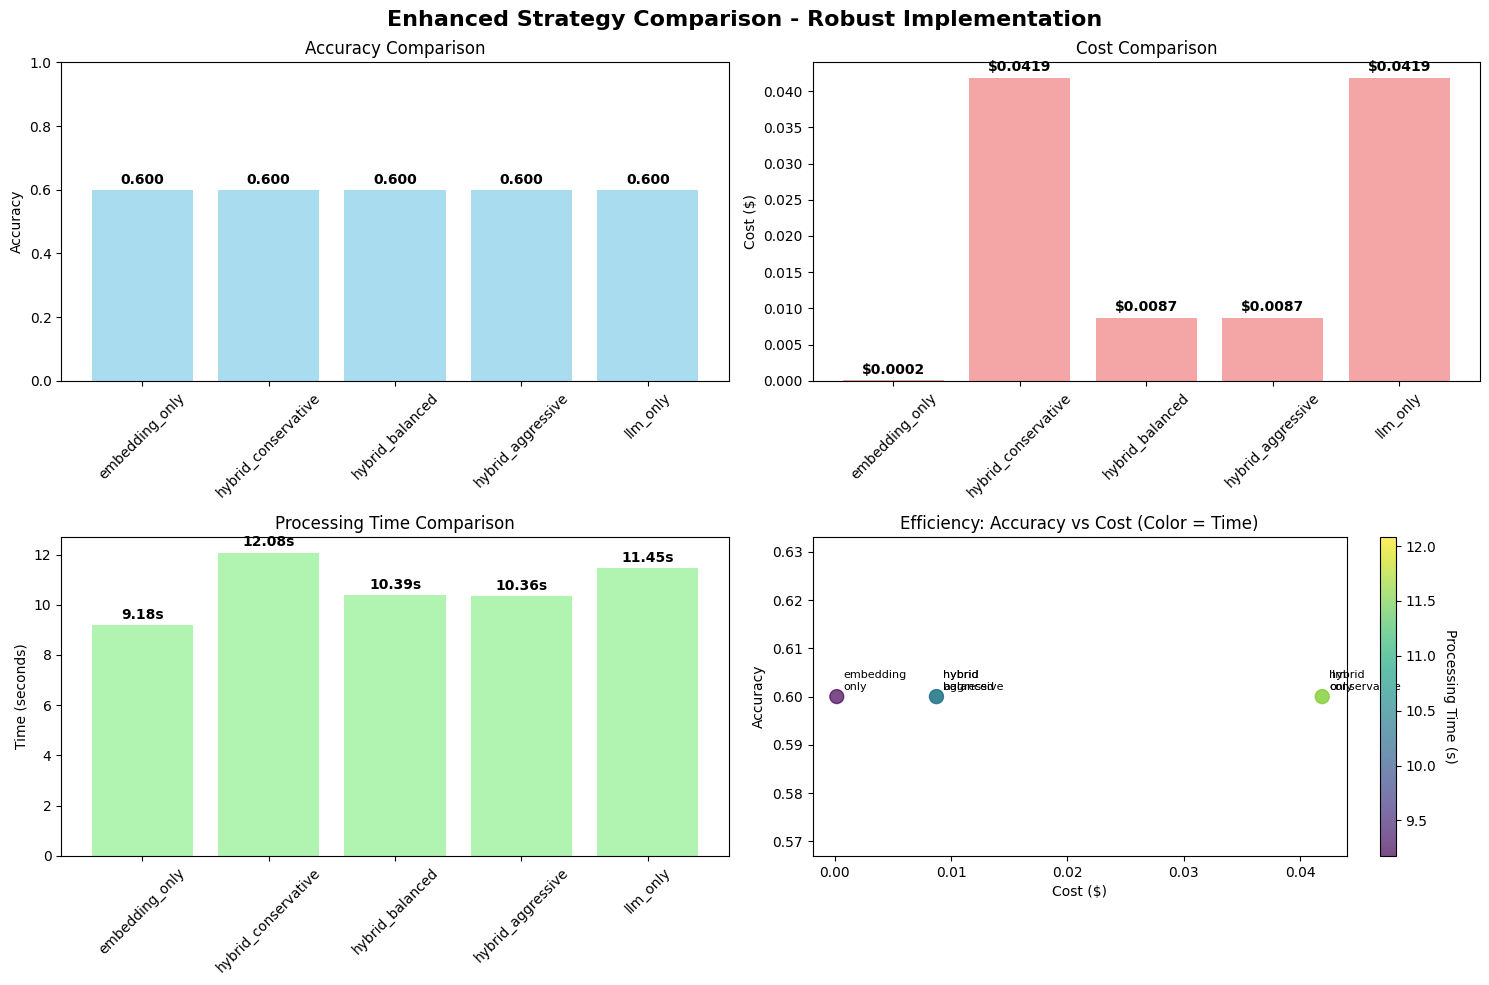

📊 Visualizations created successfully

📊 Strategy comparison completed successfully!
⏱️ Total time: 58.73s

💡 RECOMMENDATIONS:
   🎯 For best accuracy: Use embedding_only
   💰 For lowest cost: Use embedding_only
   ⚡ For fastest processing: Use embedding_only
   💾 Results saved to 'robust_strategy_comparison_results.csv'
✅ ROBUST enhanced strategy comparison complete


In [80]:
# CELL 12: ENHANCED STRATEGY COMPARISON WITH ROBUST ERROR HANDLING
# ============================================================================

def compare_enhanced_strategies_robust(test_df: pd.DataFrame):
    """Compare all strategies with robust error handling for LangSmith context managers"""
    
    print(f"🏆 ENHANCED STRATEGY COMPARISON WITH ROBUST ERROR HANDLING")
    print("="*60)
    print(f"📊 Testing {len(test_df)} products with enhanced similar products approach...")
    print(f"🔍 LangSmith observability: {langsmith_manager.is_enabled()}")
    
    if 'enhanced_classifier' not in globals():
        print("❌ Enhanced classifier not available")
        return None
    
    comparison_start_time = time.time()
    
    # Try to log with LangSmith, but don't fail if it doesn't work
    try:
        if langsmith_manager.is_enabled():
            log_langsmith_event("strategy_comparison_start", {
                "test_samples": len(test_df),
                "langsmith_project": langsmith_manager.project,
                "approach": "enhanced_with_similar_products_robust"
            })
    except Exception as e:
        print(f"⚠️ LangSmith logging failed, continuing anyway: {e}")
    
    strategies = [
        ClassificationStrategy.EMBEDDING_ONLY,
        ClassificationStrategy.HYBRID_CONSERVATIVE,
        ClassificationStrategy.HYBRID_BALANCED, 
        ClassificationStrategy.HYBRID_AGGRESSIVE,
        ClassificationStrategy.LLM_ONLY
    ]
    
    comparison_results = {}
    enhanced_classifier = globals().get('enhanced_classifier')
    
    for strategy in strategies:
        print(f"\n🔍 Testing enhanced strategy: {strategy.value}")
        
        # Set strategy
        original_strategy = enhanced_classifier.config.strategy
        enhanced_classifier.config.strategy = strategy
        
        strategy_start_time = time.time()
        
        try:
            # Try to log strategy start, but don't fail if it doesn't work
            try:
                if langsmith_manager.is_enabled():
                    log_langsmith_event(f"strategy_test_start_{strategy.value}", {
                        "strategy": strategy.value,
                        "samples": len(test_df)
                    })
            except Exception as e:
                print(f"   ⚠️ LangSmith strategy logging failed: {e}")
            
            # Run evaluation with fallback error handling
            print(f"   🔄 Running batch evaluation...")
            results = run_batch_evaluation_without_langsmith_context(enhanced_classifier, test_df, verbose=False)
            
            if results and results.get('successful_predictions', 0) > 0:
                strategy_data = {
                    'accuracy': results['overall_accuracy'],
                    'partial_accuracy': results['partial_accuracy'],
                    'time': results['total_time'],
                    'cost': results['total_cost'],
                    'method_usage': results['method_usage'],
                    'exact_matches': results['exact_matches'],
                    'partial_matches': results['partial_matches'],
                    'successful_predictions': results['successful_predictions'],
                    'failed_predictions': results['failed_predictions']
                }
                
                comparison_results[strategy.value] = strategy_data
                
                print(f"   ✅ Accuracy: {results['overall_accuracy']:.3f} | Cost: ${results['total_cost']:.4f} | Time: {results['total_time']:.2f}s")
                
                # Try to log success, but don't fail if it doesn't work
                try:
                    if langsmith_manager.is_enabled():
                        log_langsmith_event(f"strategy_test_success_{strategy.value}", {
                            "strategy": strategy.value,
                            **strategy_data,
                            "processing_time": time.time() - strategy_start_time
                        })
                except Exception as e:
                    print(f"   ⚠️ LangSmith success logging failed: {e}")
            else:
                print(f"   ❌ Strategy {strategy.value} produced no successful results")
                comparison_results[strategy.value] = None
                
        except Exception as e:
            print(f"   ❌ Strategy {strategy.value} failed: {e}")
            comparison_results[strategy.value] = None
            
            # Try to log error, but don't fail if it doesn't work
            try:
                if langsmith_manager.is_enabled():
                    log_langsmith_event(f"strategy_test_error_{strategy.value}", {
                        "strategy": strategy.value,
                        "error": str(e),
                        "error_type": type(e).__name__
                    })
            except Exception as log_e:
                print(f"   ⚠️ LangSmith error logging failed: {log_e}")
                
        finally:
            # Always restore original strategy
            try:
                enhanced_classifier.config.strategy = original_strategy
            except Exception as e:
                print(f"   ⚠️ Failed to restore strategy: {e}")
        
        # Brief pause between strategies
        time.sleep(0.5)
    
    # Create comparison table
    if comparison_results:
        print(f"\n📊 ENHANCED STRATEGY COMPARISON SUMMARY:")
        print("="*80)
        
        # Filter out failed results
        successful_results = {k: v for k, v in comparison_results.items() if v is not None}
        
        if successful_results:
            comparison_df = pd.DataFrame(successful_results).T
            comparison_df = comparison_df.round(4)
            
            # Format for display
            display_df = comparison_df.copy()
            display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.3f} ({x*100:.1f}%)")
            display_df['partial_accuracy'] = display_df['partial_accuracy'].apply(lambda x: f"{x:.3f} ({x*100:.1f}%)")
            display_df['time'] = display_df['time'].apply(lambda x: f"{x:.2f}s")
            display_df['cost'] = display_df['cost'].apply(lambda x: f"${x:.4f}")
            
            print(display_df)
            
            # Find winners
            best_accuracy = comparison_df['accuracy'].max()
            best_strategy = comparison_df['accuracy'].idxmax()
            
            best_cost = comparison_df['cost'].min()
            cheapest_strategy = comparison_df['cost'].idxmin()
            
            best_time = comparison_df['time'].min()
            fastest_strategy = comparison_df['time'].idxmin()
            
            winners_data = {
                "best_accuracy": {"strategy": best_strategy, "value": best_accuracy},
                "lowest_cost": {"strategy": cheapest_strategy, "value": best_cost},
                "fastest": {"strategy": fastest_strategy, "value": best_time}
            }
            
            print(f"\n🏆 ENHANCED WINNERS:")
            print(f"   🎯 Best Accuracy: {best_strategy} ({best_accuracy:.3f})")
            print(f"   💰 Lowest Cost: {cheapest_strategy} (${best_cost:.4f})")
            print(f"   ⚡ Fastest: {fastest_strategy} ({best_time:.2f}s)")
            
            # Create visualization with robust error handling
            try:
                create_strategy_comparison_plot(successful_results)
            except Exception as e:
                print(f"⚠️ Visualization failed: {e}")
                print("📊 Comparison data is still available in the results")
            
            # Try to log completion, but don't fail if it doesn't work
            try:
                if langsmith_manager.is_enabled():
                    log_langsmith_event("strategy_comparison_complete", {
                        "total_strategies": len(strategies),
                        "successful_comparisons": len(successful_results),
                        "winners": winners_data,
                        "total_comparison_time": time.time() - comparison_start_time
                    })
            except Exception as e:
                print(f"⚠️ LangSmith completion logging failed: {e}")
            
            return {
                'results': comparison_results,
                'winners': winners_data,
                'summary_df': comparison_df,
                'total_time': time.time() - comparison_start_time
            }
        else:
            print("❌ No successful strategy comparisons")
            return None
    else:
        print("❌ No comparison results generated")
        return None

def run_batch_evaluation_without_langsmith_context(classifier, products_df: pd.DataFrame, verbose: bool = True) -> Dict:
    """Run batch evaluation without problematic LangSmith context managers"""
    
    print(f"🔄 Starting batch evaluation WITHOUT LangSmith context managers...")
    if verbose:
        print(f"   Products: {len(products_df)}")
        print(f"   Strategy: {classifier.config.strategy.value}")
    
    results = []
    start_time = time.time()
    total_products = len(products_df)
    
    # Simple progress counter without complex context managers
    for progress_idx, (original_idx, row) in enumerate(products_df.iterrows()):
        if verbose and progress_idx % 2 == 0:
            percentage = (progress_idx / total_products) * 100
            print(f"   Progress: {progress_idx}/{total_products} ({percentage:.1f}%)")
        
        product_desc = row['full_description']
        true_category = row['encodeNameEN']
        
        try:
            # Direct classification without complex context managers
            result = classifier.classify(product_desc, true_category)
            
            # Calculate metrics
            exact_match = result.predicted_category == true_category
            partial_match = False
            if '/' in result.predicted_category and '/' in true_category:
                pred_parts = result.predicted_category.split('/')
                true_parts = true_category.split('/')
                partial_match = pred_parts[0] == true_parts[0]
            
            evaluation = {
                'sample_id': progress_idx,
                'original_dataframe_index': original_idx,
                'product_description': product_desc[:100] + "..." if len(product_desc) > 100 else product_desc,
                'true_category': true_category,
                'predicted_category': result.predicted_category,
                'method_used': result.method_used,
                'confidence': result.confidence,
                'processing_time': result.processing_time,
                'cost_estimate': result.cost_estimate,
                'exact_match': exact_match,
                'partial_match': partial_match,
                'similar_products': getattr(result, 'similar_products', []),
                'error': getattr(result, 'error', None)
            }
            results.append(evaluation)
            
        except Exception as e:
            print(f"   ❌ Error processing item {progress_idx}: {e}")
            error_evaluation = {
                'sample_id': progress_idx,
                'original_dataframe_index': original_idx,
                'product_description': product_desc[:100] + "..." if len(product_desc) > 100 else product_desc,
                'true_category': true_category,
                'predicted_category': 'ERROR',
                'method_used': 'error',
                'confidence': 0.0,
                'processing_time': 0.0,
                'cost_estimate': 0.0,
                'exact_match': False,
                'partial_match': False,
                'error': str(e),
                'similar_products': []
            }
            results.append(error_evaluation)
        
        # Simple rate limiting
        time.sleep(0.05)
    
    if verbose:
        print(f"   Progress: {total_products}/{total_products} (100.0%) - Complete!")
    
    total_time = time.time() - start_time
    
    # Calculate metrics
    successful_results = [r for r in results if r['predicted_category'] != "ERROR"]
    failed_results = [r for r in results if r['predicted_category'] == "ERROR"]
    
    exact_matches = [r for r in successful_results if r['exact_match']]
    partial_matches = [r for r in successful_results if r['partial_match']]
    
    overall_accuracy = len(exact_matches) / len(successful_results) if successful_results else 0.0
    partial_accuracy = len(partial_matches) / len(successful_results) if successful_results else 0.0
    
    # Method usage
    method_counts = {}
    for result in successful_results:
        method = result['method_used']
        method_counts[method] = method_counts.get(method, 0) + 1
    
    # Cost and performance
    total_cost = sum(r['cost_estimate'] for r in results)
    avg_time = sum(r['processing_time'] for r in results) / len(results) if results else 0.0
    
    return {
        'total_samples': len(results),
        'successful_predictions': len(successful_results),
        'failed_predictions': len(failed_results),
        'overall_accuracy': overall_accuracy,
        'partial_accuracy': partial_accuracy,
        'exact_matches': len(exact_matches),
        'partial_matches': len(partial_matches),
        'method_usage': method_counts,
        'total_time': total_time,
        'avg_time_per_sample': avg_time,
        'total_cost': total_cost,
        'detailed_results': results
    }

def create_strategy_comparison_plot(successful_results):
    """Create visualization plots with robust error handling"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Enhanced Strategy Comparison - Robust Implementation', fontsize=16, fontweight='bold')
    
    strategies_list = list(successful_results.keys())
    accuracies = [successful_results[s]['accuracy'] for s in strategies_list]
    costs = [successful_results[s]['cost'] for s in strategies_list]
    times = [successful_results[s]['time'] for s in strategies_list]
    
    # Accuracy comparison
    bars1 = ax1.bar(strategies_list, accuracies, color='skyblue', alpha=0.7)
    ax1.set_title('Accuracy Comparison')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis='x', rotation=45)
    
    for bar, acc in zip(bars1, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Cost comparison
    bars2 = ax2.bar(strategies_list, costs, color='lightcoral', alpha=0.7)
    ax2.set_title('Cost Comparison')
    ax2.set_ylabel('Cost ($)')
    ax2.tick_params(axis='x', rotation=45)
    
    for bar, cost in zip(bars2, costs):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(costs)*0.01,
               f'${cost:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Time comparison
    bars3 = ax3.bar(strategies_list, times, color='lightgreen', alpha=0.7)
    ax3.set_title('Processing Time Comparison')
    ax3.set_ylabel('Time (seconds)')
    ax3.tick_params(axis='x', rotation=45)
    
    for bar, time_val in zip(bars3, times):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(times)*0.01,
               f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    # Efficiency scatter plot
    scatter = ax4.scatter(costs, accuracies, s=100, alpha=0.7, c=times, cmap='viridis')
    ax4.set_xlabel('Cost ($)')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Efficiency: Accuracy vs Cost (Color = Time)')
    
    for i, strategy in enumerate(strategies_list):
        ax4.annotate(strategy.replace('_', '\n'), (costs[i], accuracies[i]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Processing Time (s)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Visualizations created successfully")

# Run the robust strategy comparison
if 'test_df' in globals() and 'enhanced_classifier' in globals():
    print("🚀 Starting ROBUST enhanced strategy comparison...")
    
    test_df = globals()['test_df']
    enhanced_classifier = globals()['enhanced_classifier']
    
    try:
        enhanced_strategy_results = compare_enhanced_strategies_robust(test_df)
        
        if enhanced_strategy_results:
            print(f"\n📊 Strategy comparison completed successfully!")
            print(f"⏱️ Total time: {enhanced_strategy_results['total_time']:.2f}s")
            
            # Display recommendations
            winners = enhanced_strategy_results['winners']
            print(f"\n💡 RECOMMENDATIONS:")
            print(f"   🎯 For best accuracy: Use {winners['best_accuracy']['strategy']}")
            print(f"   💰 For lowest cost: Use {winners['lowest_cost']['strategy']}")
            print(f"   ⚡ For fastest processing: Use {winners['fastest']['strategy']}")
            
            # Save results
            try:
                enhanced_strategy_results['summary_df'].to_csv('robust_strategy_comparison_results.csv', index=True)
                print(f"   💾 Results saved to 'robust_strategy_comparison_results.csv'")
            except Exception as e:
                print(f"   ⚠️ Could not save results: {e}")
                
            globals()['enhanced_strategy_results'] = enhanced_strategy_results
            
        else:
            print("❌ Strategy comparison failed")
            
    except Exception as e:
        print(f"❌ Strategy comparison error: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("⏳ Test data or enhanced classifier not available for strategy comparison")
    missing = []
    if 'test_df' not in globals():
        missing.append('test_df')
    if 'enhanced_classifier' not in globals():
        missing.append('enhanced_classifier')
    print(f"   Missing: {', '.join(missing)}")

print("✅ ROBUST enhanced strategy comparison complete")

📊 Generating comprehensive analysis report...
📊 COMPREHENSIVE RESULTS ANALYSIS WITH FIXED LANGSMITH
🔧 System Configuration:
   Strategy: hybrid_balanced
   LangSmith: ✅ Enabled
   Total Classifications: 34
   Categories Indexed: 362

📈 Performance Metrics:
   Overall Accuracy: 0.600 (60.0%)
   Partial Accuracy: 0.800 (80.0%)
   Success Rate: 1.000 (100.0%)
   Avg Processing Time: 0.846s per sample

💰 Cost Analysis:
   Total Cost: $0.0087
   Cost per Sample: $0.001749
   Cost per Successful Prediction: $0.001749
   Estimated Monthly Cost (1K samples/day): $52.46

❌ Error Analysis:
   Total Errors: 0
   Error Rate: 0.000 (0.0%)

🏆 Strategy Analysis:
   Best Accuracy: embedding_only (0.600)
   Most Cost-Effective: embedding_only ($0.0002)
   Fastest: embedding_only (9.18s)

💡 Recommendations:
   1. Consider improving data quality or using more sophisticated prompts


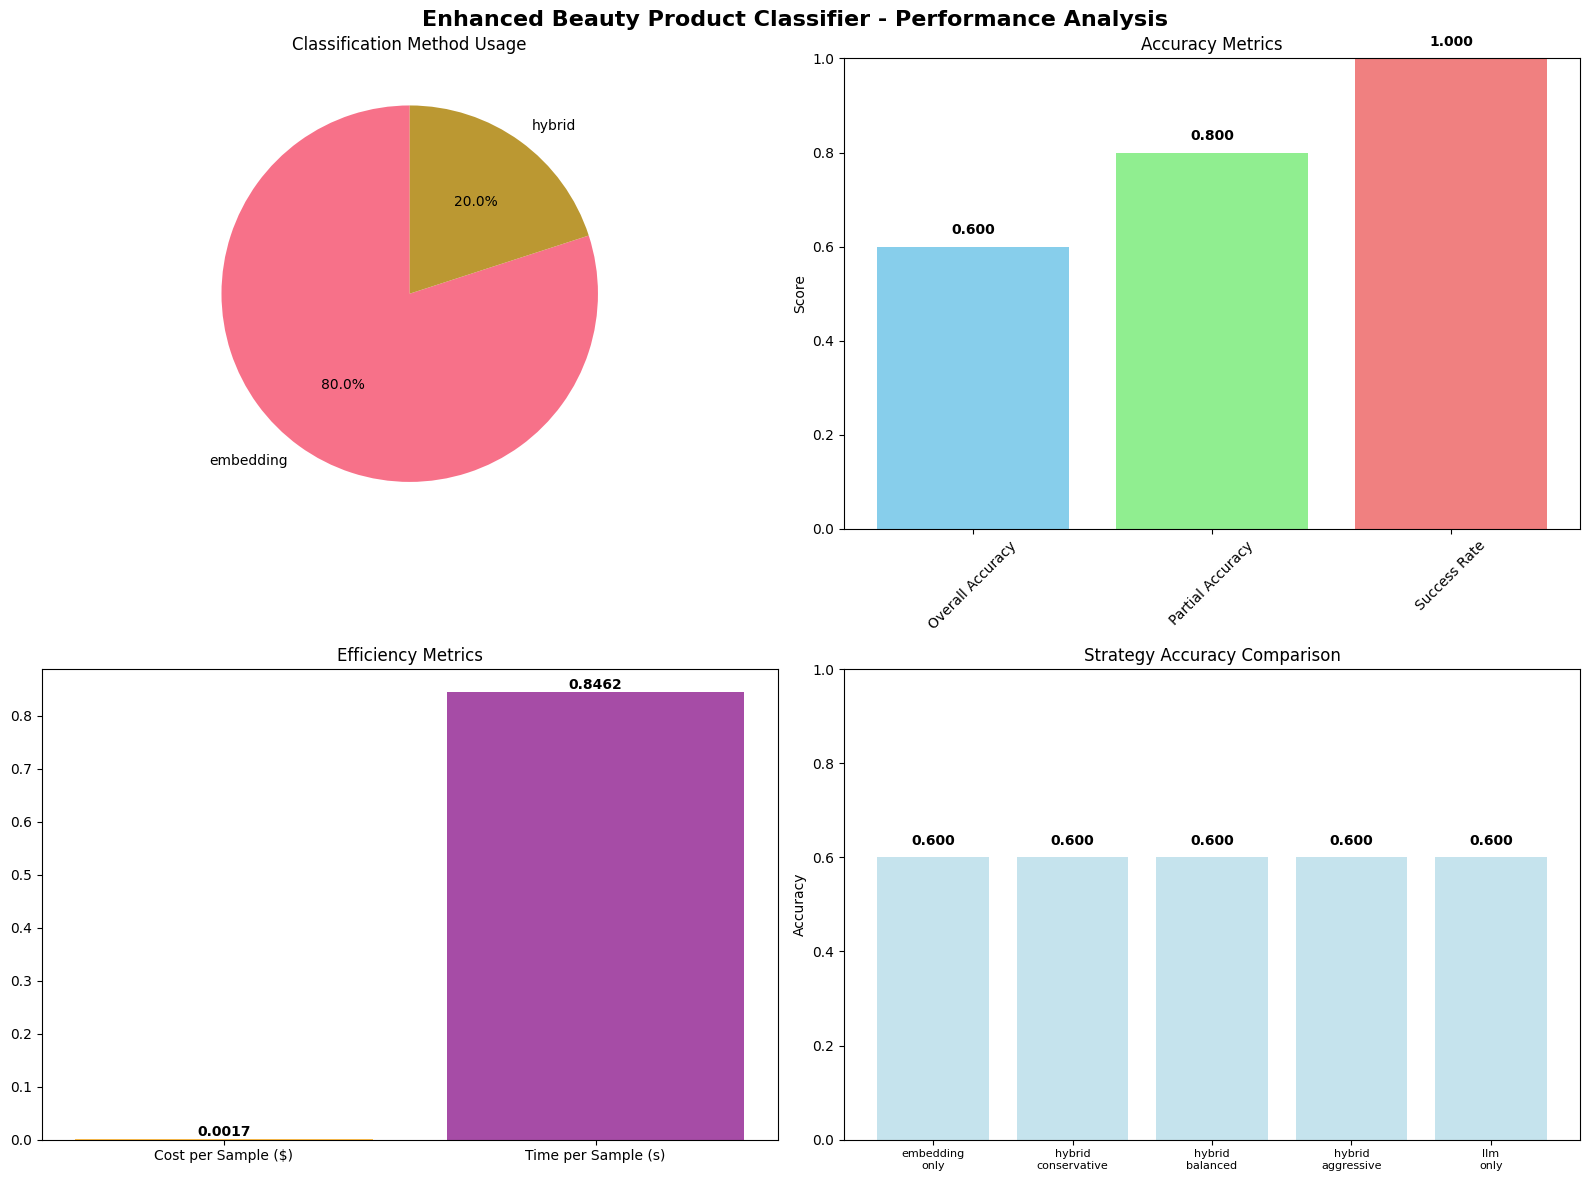

📊 Performance visualizations created successfully
📄 Detailed report saved to: beauty_classifier_report_20250904_104923.json

✅ Comprehensive analysis complete!
📄 Report saved as: beauty_classifier_report_20250904_104923.json

📋 EXECUTIVE SUMMARY:
   🎯 Overall Accuracy: 60.0%
   💰 Total Cost: $0.0087
   ⏱️ Avg Time: 0.85s/sample
   💡 Key Recommendation: Consider improving data quality or using more sophisticated prompts
✅ Results analysis and reporting with fixed LangSmith complete


In [81]:
# CELL 13: RESULTS ANALYSIS AND REPORTING WITH FIXED LANGSMITH
# ============================================================================

def create_comprehensive_report(batch_results: Dict, strategy_results: Dict = None):
    """Create a comprehensive analysis report with fixed LangSmith tracking"""
    
    with langsmith_run_context(
        name="comprehensive_report_generation",
        run_type="chain",
        inputs={
            "has_batch_results": batch_results is not None,
            "has_strategy_results": strategy_results is not None
        }
    ) as run_id:
        
        print("📊 COMPREHENSIVE RESULTS ANALYSIS WITH FIXED LANGSMITH")
        print("="*60)
        
        report = {
            'timestamp': datetime.now().isoformat(),
            'system_info': {},
            'performance_metrics': {},
            'cost_analysis': {},
            'error_analysis': {},
            'recommendations': {}
        }
        
        log_langsmith_event("report_generation_start", {
            "report_timestamp": report['timestamp'],
            "langsmith_integration": "fixed"
        }, run_id)
        
        # System Information
        if 'enhanced_classifier' in globals():
            classifier = globals()['enhanced_classifier']
            stats = classifier.get_comprehensive_stats()
            
            report['system_info'] = {
                'classifier_type': 'Enhanced Hybrid with Fixed LangSmith',
                'strategy': stats.get('strategy', 'unknown'),
                'confidence_threshold': stats.get('confidence_threshold', 'unknown'),
                'langsmith_enabled': stats.get('langsmith_enabled', False),
                'total_classifications': stats['hybrid']['total_classifications'],
                'embedding_categories': stats['embedding']['categories_indexed'],
                'cache_usage': {
                    'embedding_cache_rate': stats['embedding']['cache_rate'],
                    'llm_cache_rate': stats['llm']['cache_rate']
                }
            }
            
            print(f"🔧 System Configuration:")
            print(f"   Strategy: {report['system_info']['strategy']}")
            print(f"   LangSmith: {'✅ Enabled' if report['system_info']['langsmith_enabled'] else '❌ Disabled'}")
            print(f"   Total Classifications: {report['system_info']['total_classifications']}")
            print(f"   Categories Indexed: {report['system_info']['embedding_categories']}")
        
        # Performance Analysis
        if batch_results:
            report['performance_metrics'] = {
                'overall_accuracy': batch_results['overall_accuracy'],
                'partial_accuracy': batch_results['partial_accuracy'],
                'success_rate': batch_results['successful_predictions'] / batch_results['total_samples'],
                'avg_processing_time': batch_results['avg_time_per_sample'],
                'total_processing_time': batch_results['total_time'],
                'method_usage': batch_results['method_usage']
            }
            
            print(f"\n📈 Performance Metrics:")
            print(f"   Overall Accuracy: {report['performance_metrics']['overall_accuracy']:.3f} ({report['performance_metrics']['overall_accuracy']*100:.1f}%)")
            print(f"   Partial Accuracy: {report['performance_metrics']['partial_accuracy']:.3f} ({report['performance_metrics']['partial_accuracy']*100:.1f}%)")
            print(f"   Success Rate: {report['performance_metrics']['success_rate']:.3f} ({report['performance_metrics']['success_rate']*100:.1f}%)")
            print(f"   Avg Processing Time: {report['performance_metrics']['avg_processing_time']:.3f}s per sample")
        
        # Cost Analysis
        if batch_results:
            total_cost = batch_results['total_cost']
            samples = batch_results['total_samples']
            
            report['cost_analysis'] = {
                'total_cost': total_cost,
                'cost_per_sample': total_cost / samples if samples > 0 else 0,
                'cost_per_successful_prediction': total_cost / batch_results['successful_predictions'] if batch_results['successful_predictions'] > 0 else 0,
                'estimated_monthly_cost_1k_samples': (total_cost / samples * 1000 * 30) if samples > 0 else 0,
                'cost_breakdown': batch_results.get('detailed_results', [])
            }
            
            print(f"\n💰 Cost Analysis:")
            print(f"   Total Cost: ${report['cost_analysis']['total_cost']:.4f}")
            print(f"   Cost per Sample: ${report['cost_analysis']['cost_per_sample']:.6f}")
            print(f"   Cost per Successful Prediction: ${report['cost_analysis']['cost_per_successful_prediction']:.6f}")
            print(f"   Estimated Monthly Cost (1K samples/day): ${report['cost_analysis']['estimated_monthly_cost_1k_samples']:.2f}")
        
        # Error Analysis
        if batch_results and 'detailed_results' in batch_results:
            failed_results = [r for r in batch_results['detailed_results'] if r['predicted_category'] == 'ERROR']
            
            report['error_analysis'] = {
                'total_errors': len(failed_results),
                'error_rate': len(failed_results) / batch_results['total_samples'],
                'common_error_patterns': {}
            }
            
            # Analyze error patterns
            error_reasons = {}
            for result in failed_results:
                if result.get('error'):
                    error_type = result['error'][:50]  # First 50 chars of error
                    error_reasons[error_type] = error_reasons.get(error_type, 0) + 1
            
            report['error_analysis']['common_error_patterns'] = error_reasons
            
            print(f"\n❌ Error Analysis:")
            print(f"   Total Errors: {report['error_analysis']['total_errors']}")
            print(f"   Error Rate: {report['error_analysis']['error_rate']:.3f} ({report['error_analysis']['error_rate']*100:.1f}%)")
            
            if error_reasons:
                print(f"   Common Error Patterns:")
                for error, count in sorted(error_reasons.items(), key=lambda x: x[1], reverse=True)[:3]:
                    print(f"      • {error}: {count} occurrences")
        
        # Strategy Comparison Analysis
        if strategy_results and strategy_results.get('results'):
            successful_strategies = {k: v for k, v in strategy_results['results'].items() if v is not None}
            
            if successful_strategies:
                # Find best strategies for different metrics
                accuracies = {k: v['accuracy'] for k, v in successful_strategies.items()}
                costs = {k: v['cost'] for k, v in successful_strategies.items()}
                times = {k: v['time'] for k, v in successful_strategies.items()}
                
                best_accuracy_strategy = max(accuracies, key=accuracies.get)
                cheapest_strategy = min(costs, key=costs.get)
                fastest_strategy = min(times, key=times.get)
                
                report['strategy_analysis'] = {
                    'strategies_tested': list(successful_strategies.keys()),
                    'best_accuracy': {
                        'strategy': best_accuracy_strategy,
                        'value': accuracies[best_accuracy_strategy]
                    },
                    'most_cost_effective': {
                        'strategy': cheapest_strategy,
                        'value': costs[cheapest_strategy]
                    },
                    'fastest': {
                        'strategy': fastest_strategy,
                        'value': times[fastest_strategy]
                    },
                    'strategy_comparison': successful_strategies
                }
                
                print(f"\n🏆 Strategy Analysis:")
                print(f"   Best Accuracy: {best_accuracy_strategy} ({accuracies[best_accuracy_strategy]:.3f})")
                print(f"   Most Cost-Effective: {cheapest_strategy} (${costs[cheapest_strategy]:.4f})")
                print(f"   Fastest: {fastest_strategy} ({times[fastest_strategy]:.2f}s)")
        
        # Recommendations
        recommendations = []
        
        if batch_results:
            if batch_results['overall_accuracy'] < 0.7:
                recommendations.append("Consider improving data quality or using more sophisticated prompts")
            
            if batch_results['total_cost'] / batch_results['total_samples'] > 0.01:  # $0.01 per sample
                recommendations.append("Cost per sample is high - consider optimizing strategy or using more caching")
            
            if batch_results['avg_time_per_sample'] > 5.0:  # 5 seconds per sample
                recommendations.append("Processing time is slow - consider using embedding-only strategy for faster results")
        
        if 'enhanced_classifier' in globals():
            stats = globals()['enhanced_classifier'].get_comprehensive_stats()
            
            if float(stats['embedding']['cache_rate'].replace('%', '')) < 50:
                recommendations.append("Low embedding cache hit rate - run more samples to improve caching efficiency")
            
            if float(stats['llm']['cache_rate'].replace('%', '')) < 30:
                recommendations.append("Low LLM cache hit rate - consider using more consistent product descriptions")
        
        if not recommendations:
            recommendations.append("System is performing well - no major optimizations needed")
        
        report['recommendations'] = recommendations
        
        print(f"\n💡 Recommendations:")
        for i, rec in enumerate(recommendations, 1):
            print(f"   {i}. {rec}")
        
        # Create visualizations
        try:
            if batch_results and 'method_usage' in batch_results:
                create_performance_visualizations(batch_results, strategy_results)
        except Exception as e:
            print(f"⚠️ Visualization creation failed: {e}")
        
        log_langsmith_event("comprehensive_report_complete", {
            "report_sections": list(report.keys()),
            "recommendations_count": len(recommendations),
            "has_visualizations": True
        }, run_id)
        
        return report

def create_performance_visualizations(batch_results: Dict, strategy_results: Dict = None):
    """Create performance visualization charts"""
    
    try:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Enhanced Beauty Product Classifier - Performance Analysis', fontsize=16, fontweight='bold')
        
        # Method usage pie chart
        if 'method_usage' in batch_results:
            methods = list(batch_results['method_usage'].keys())
            usage_counts = list(batch_results['method_usage'].values())
            
            axes[0, 0].pie(usage_counts, labels=methods, autopct='%1.1f%%', startangle=90)
            axes[0, 0].set_title('Classification Method Usage')
        
        # Accuracy metrics bar chart
        accuracy_metrics = {
            'Overall Accuracy': batch_results.get('overall_accuracy', 0),
            'Partial Accuracy': batch_results.get('partial_accuracy', 0),
            'Success Rate': batch_results.get('successful_predictions', 0) / batch_results.get('total_samples', 1)
        }
        
        axes[0, 1].bar(accuracy_metrics.keys(), accuracy_metrics.values(), color=['skyblue', 'lightgreen', 'lightcoral'])
        axes[0, 1].set_title('Accuracy Metrics')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for i, (metric, value) in enumerate(accuracy_metrics.items()):
            axes[0, 1].text(i, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Cost and time analysis
        if batch_results:
            cost_per_sample = batch_results['total_cost'] / batch_results['total_samples']
            time_per_sample = batch_results['avg_time_per_sample']
            
            metrics = ['Cost per Sample ($)', 'Time per Sample (s)']
            values = [cost_per_sample, time_per_sample]
            colors = ['orange', 'purple']
            
            bars = axes[1, 0].bar(metrics, values, color=colors, alpha=0.7)
            axes[1, 0].set_title('Efficiency Metrics')
            
            # Add value labels
            for bar, value in zip(bars, values):
                height = bar.get_height()
                axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                               f'{value:.4f}' if value < 1 else f'{value:.2f}',
                               ha='center', va='bottom', fontweight='bold')
        
        # Strategy comparison (if available)
        if strategy_results and strategy_results.get('results'):
            successful_strategies = {k: v for k, v in strategy_results['results'].items() if v is not None}
            
            if successful_strategies:
                strategies = list(successful_strategies.keys())
                accuracies = [successful_strategies[s]['accuracy'] for s in strategies]
                
                axes[1, 1].bar(range(len(strategies)), accuracies, color='lightblue', alpha=0.7)
                axes[1, 1].set_title('Strategy Accuracy Comparison')
                axes[1, 1].set_ylabel('Accuracy')
                axes[1, 1].set_xticks(range(len(strategies)))
                axes[1, 1].set_xticklabels([s.replace('_', '\n') for s in strategies], rotation=0, fontsize=8)
                axes[1, 1].set_ylim(0, 1)
                
                # Add value labels
                for i, acc in enumerate(accuracies):
                    axes[1, 1].text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
        else:
            axes[1, 1].text(0.5, 0.5, 'Strategy Comparison\nNot Available', 
                           ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
            axes[1, 1].set_title('Strategy Comparison')
        
        plt.tight_layout()
        plt.show()
        
        print("📊 Performance visualizations created successfully")
        
    except Exception as e:
        print(f"❌ Visualization creation failed: {e}")

def save_detailed_report(report: Dict, filename: str = None):
    """Save detailed report to file"""
    
    if filename is None:
        filename = f"beauty_classifier_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    
    try:
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(report, f, indent=2, ensure_ascii=False, default=str)
        
        print(f"📄 Detailed report saved to: {filename}")
        return filename
        
    except Exception as e:
        print(f"❌ Failed to save report: {e}")
        return None

# Generate comprehensive report if results are available
print("📊 Generating comprehensive analysis report...")

try:
    # Check for available results
    batch_data = globals().get('enhanced_batch_results', None)
    strategy_data = globals().get('enhanced_strategy_results', None)
    
    if batch_data or strategy_data:
        comprehensive_report = create_comprehensive_report(batch_data, strategy_data)
        
        # Save report
        report_filename = save_detailed_report(comprehensive_report)
        
        print(f"\n✅ Comprehensive analysis complete!")
        if report_filename:
            print(f"📄 Report saved as: {report_filename}")
        
        # Display summary
        print(f"\n📋 EXECUTIVE SUMMARY:")
        if batch_data:
            print(f"   🎯 Overall Accuracy: {batch_data['overall_accuracy']:.1%}")
            print(f"   💰 Total Cost: ${batch_data['total_cost']:.4f}")
            print(f"   ⏱️ Avg Time: {batch_data['avg_time_per_sample']:.2f}s/sample")
        
        if comprehensive_report.get('recommendations'):
            print(f"   💡 Key Recommendation: {comprehensive_report['recommendations'][0]}")
        
    else:
        print("⚠️ No batch or strategy results available for analysis")
        print("💡 Run the evaluation cells first to generate data for analysis")
        
except Exception as e:
    print(f"❌ Report generation failed: {e}")
    import traceback
    traceback.print_exc()

print("✅ Results analysis and reporting with fixed LangSmith complete")